In [1]:
import os
import time
import zipfile
import pickle
import warnings
from glob import glob
from os import path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tabulate import tabulate
from IPython.display import display

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_text
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    classification_report,
    confusion_matrix,
)

from scipy.stats import spearmanr

In [2]:


# Build path to CSV files inside the nested /data folder
data_folder = os.path.join(
"data"
)

nf_csv_path = os.path.join(data_folder, "NF-UNSW-NB15-v3.csv")
feature_csv_path = os.path.join(data_folder, "NetFlow_v3_Features.csv")
protocol_csv_path = os.path.join(data_folder, "Protocols.csv")

# Load CSV files
print("Loading CSV files...")
data = pd.read_csv(nf_csv_path)
feature = pd.read_csv(feature_csv_path)
protocol = pd.read_csv(protocol_csv_path)

print(f" data : {data.shape[0]:,} rows × {data.shape[1]} cols")
print(f" feature : {feature.shape[0]:,} rows × {feature.shape[1]} cols")
print(f" protocol : {protocol.shape[0]:,} rows × {protocol.shape[1]} cols")

Loading CSV files...
 data : 2,365,424 rows × 55 cols
 feature : 53 rows × 2 cols
 protocol : 152 rows × 5 cols


In [3]:
# ===== Step 1: Inspect Data Shape, Types, Missing Values & Duplicates =====
print(f"Shape: {data.shape}")
print(f"\nDuplicate rows: {data.duplicated().sum()}")
print(f"\n--- Missing Values ---")
missing = data.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")
print(f"\nTotal missing values: {data.isnull().sum().sum()}")
print(f"\n--- Data Types ---")
print(data.dtypes)

Shape: (2365424, 55)

Duplicate rows: 14815

--- Missing Values ---
SRC_TO_DST_SECOND_BYTES    63425
dtype: int64

Total missing values: 63425

--- Data Types ---
FLOW_START_MILLISECONDS          int64
FLOW_END_MILLISECONDS            int64
IPV4_SRC_ADDR                      str
L4_SRC_PORT                      int64
IPV4_DST_ADDR                      str
L4_DST_PORT                      int64
PROTOCOL                         int64
L7_PROTO                       float64
IN_BYTES                         int64
IN_PKTS                          int64
OUT_BYTES                        int64
OUT_PKTS                         int64
TCP_FLAGS                        int64
CLIENT_TCP_FLAGS                 int64
SERVER_TCP_FLAGS                 int64
FLOW_DURATION_MILLISECONDS       int64
DURATION_IN                      int64
DURATION_OUT                     int64
MIN_TTL                          int64
MAX_TTL                          int64
LONGEST_FLOW_PKT                 int64
SHORTEST_FLOW_PKT 

In [4]:
# ===== Step 2: Remove Duplicate Rows =====
before = len(data)
data.drop_duplicates(inplace=True)
data.reset_index(drop=True, inplace=True)
after = len(data)
print(f"Rows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Duplicates removed: {before - after:,}")
print(f"Remaining duplicates: {data.duplicated().sum()}")

Rows before: 2,365,424
Rows after:  2,350,609
Duplicates removed: 14,815
Remaining duplicates: 0


In [5]:
# ===== Step 3: Handle Missing Values, Inf Values & Fix Data Types =====

# 3a. Check for missing values
missing = data.isnull().sum()
print("Columns with missing values:")
print(missing[missing > 0] if missing.sum() > 0 else "  None")

# 3b. Check for infinite values in float columns
float_cols = data.select_dtypes(include=['float64']).columns.tolist()
print(f"\nFloat columns: {float_cols}")
for col in float_cols:
    n_nan = data[col].isnull().sum()
    n_inf = np.isinf(data[col]).sum()
    print(f"  {col}: NaN={n_nan:,}, Inf={n_inf:,}")

# 3c. Replace NaN and Inf with 0 in float columns, then cast to int
for col in float_cols:
    data[col] = data[col].replace([np.inf, -np.inf], 0).fillna(0).astype(np.int64)
    print(f"  {col} -> {data[col].dtype}")

# 3d. Confirm clean state
print(f"\nTotal missing values remaining: {data.isnull().sum().sum()}")
remaining_floats = data.select_dtypes(include=['float64']).columns.tolist()
print(f"Float columns remaining: {remaining_floats}")

Columns with missing values:
SRC_TO_DST_SECOND_BYTES    50101
dtype: int64

Float columns: ['L7_PROTO', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES']
  L7_PROTO: NaN=0, Inf=0
  SRC_TO_DST_SECOND_BYTES: NaN=50,101, Inf=59,024
  DST_TO_SRC_SECOND_BYTES: NaN=0, Inf=109,125
  L7_PROTO -> int64
  SRC_TO_DST_SECOND_BYTES -> int64
  DST_TO_SRC_SECOND_BYTES -> int64

Total missing values remaining: 0
Float columns remaining: []


In [6]:
# ===== Step 4: Drop High-Cardinality IP Address Columns =====
# IP addresses are high-cardinality strings that don't generalize to unseen traffic
drop_cols = ['IPV4_SRC_ADDR', 'IPV4_DST_ADDR']
print(f"Columns before: {data.shape[1]}")
print(f"Dropping: {drop_cols}")
data.drop(columns=drop_cols, inplace=True)
print(f"Columns after: {data.shape[1]}")
print(f"Object columns remaining: {data.select_dtypes(include=[object]).columns.tolist()}")

Columns before: 55
Dropping: ['IPV4_SRC_ADDR', 'IPV4_DST_ADDR']
Columns after: 53
Object columns remaining: ['Attack']


C:\Users\riomar\AppData\Local\Temp\ipykernel_31776\1517831933.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"Object columns remaining: {data.select_dtypes(include=[object]).columns.tolist()}")


Attack Label Encoding:
   0 = Analysis             (     1,226 samples)
   1 = Backdoor             (     4,658 samples)
   2 = Benign               ( 2,222,930 samples)
   3 = DoS                  (     5,971 samples)
   4 = Exploits             (    42,744 samples)
   5 = Fuzzers              (    33,816 samples)
   6 = Generic              (    19,651 samples)
   7 = Reconnaissance       (    17,074 samples)
   8 = Shellcode            (     2,381 samples)
   9 = Worms                (       158 samples)

Unique attack types: 10
Label column (binary): [0 1]


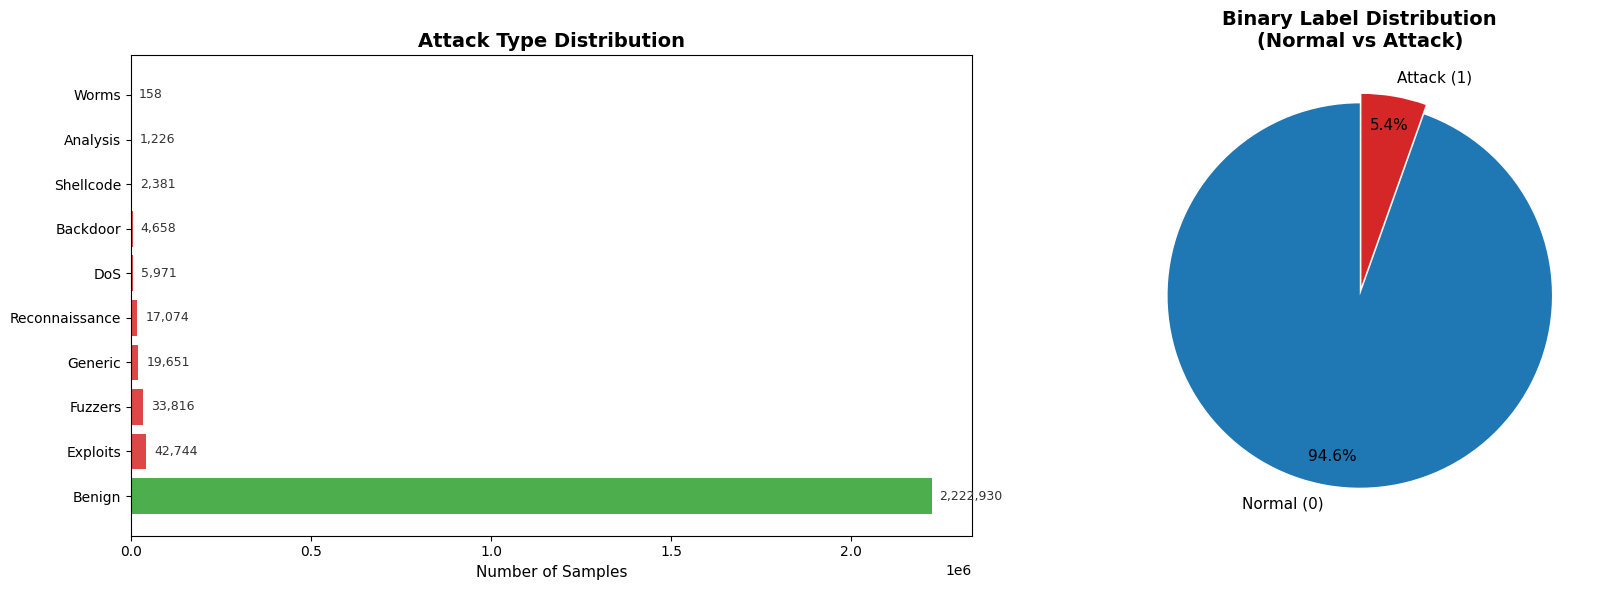

In [7]:
# ===== Step 5: Encode Categorical Variables =====
# Label-encode the 'Attack' column for multi-class classification
# 'Label' (binary 0/1) is already numeric — no action needed

le_attack = LabelEncoder()
data['Attack_Label'] = le_attack.fit_transform(data['Attack']) # type: ignore

# Print the mapping
print("Attack Label Encoding:")
for label, encoded in sorted(zip(le_attack.classes_, le_attack.transform(le_attack.classes_)), key=lambda x: x[1]): # type: ignore
    count = (data['Attack_Label'] == encoded).sum()
    print(f"  {encoded:>2} = {label:<20} ({count:>10,} samples)")

print(f"\nUnique attack types: {data['Attack'].nunique()}")
print(f"Label column (binary): {data['Label'].unique()}")

# --- Visualization: Attack Type Distribution ---
attack_counts = data['Attack'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart
colors = ['#2ca02c' if t == 'Benign' else '#d62728' for t in attack_counts.index]
bars = axes[0].barh(range(len(attack_counts)), attack_counts.values, color=colors, alpha=0.85)
axes[0].set_yticks(range(len(attack_counts)))
axes[0].set_yticklabels(attack_counts.index, fontsize=10)
axes[0].set_xlabel('Number of Samples', fontsize=11)
axes[0].set_title('Attack Type Distribution', fontsize=14, fontweight='bold')
for i, (val, name) in enumerate(zip(attack_counts.values, attack_counts.index)):
    axes[0].text(val + attack_counts.values.max() * 0.01, i, f'{val:,}',
                 va='center', fontsize=9, color='#333')

# Pie chart for binary split
binary_counts = data['Label'].value_counts().sort_index()
labels_pie = ['Normal (0)', 'Attack (1)']
colors_pie = ['#1f77b4', '#d62728']
explode = (0, 0.05)
axes[1].pie(binary_counts.values, labels=labels_pie, colors=colors_pie,
            explode=explode, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11}, pctdistance=0.85)
axes[1].set_title('Binary Label Distribution\n(Normal vs Attack)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
# ===== Step 6: Final Dedup & Verify Cleaned Data =====

# After dropping IP columns, some rows that differed only by IP are now duplicates
new_dupes = data.duplicated().sum()
if new_dupes > 0:
    print(f"New duplicates after IP column removal: {new_dupes}")
    data.drop_duplicates(inplace=True)
    data.reset_index(drop=True, inplace=True)
    print(f"Removed. New shape: {data.shape}")

print("=" * 60)
print("DATA CLEANING SUMMARY")
print("=" * 60)
print(f"Final shape: {data.shape}")
print(f"Duplicates: {data.duplicated().sum()}")
print(f"Missing values: {data.isnull().sum().sum()}")
print(f"Inf values: {np.isinf(data.select_dtypes(include=[np.number])).sum().sum()}")
print(f"\n--- Column Types ---")
print(data.dtypes.value_counts())
print(f"\n--- Object Columns (non-numeric) ---")
obj_cols = data.select_dtypes(include=['object']).columns.tolist()
print(f"{obj_cols}  (Attack kept as reference; Attack_Label is the encoded version)")
print(f"\n--- First 5 Rows ---")
display(data.head())

New duplicates after IP column removal: 613
Removed. New shape: (2349996, 54)
DATA CLEANING SUMMARY
Final shape: (2349996, 54)
Duplicates: 0
Missing values: 0
Inf values: 0

--- Column Types ---
int64    53
str       1
Name: count, dtype: int64

--- Object Columns (non-numeric) ---
['Attack']  (Attack kept as reference; Attack_Label is the encoded version)

--- First 5 Rows ---


C:\Users\riomar\AppData\Local\Temp\ipykernel_31776\227698301.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = data.select_dtypes(include=['object']).columns.tolist()


,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,L4_SRC_PORT,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,...,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack,Attack_Label
0,1424242193040,1424242193043,4894,53,17,5,146,2,178,2,...,0,0,0,0,0,0,0,0,Benign,2
1,1424242192744,1424242193079,52671,31992,6,11,4704,28,2976,28,...,91,12,19,0,90,12,19,0,Benign,2
2,1424242190649,1424242193109,47290,6881,6,37,13662,238,548216,438,...,1843,10,119,0,1843,5,88,0,Benign,2
3,1424242193145,1424242193146,43310,53,17,5,146,2,178,2,...,0,0,0,0,0,0,0,0,Benign,2
4,1424242193239,1424242193241,45870,53,17,5,130,2,162,2,...,0,0,0,0,0,0,0,0,Benign,2


Web port flows: 202,100 / 2,349,996

Engineered 12 new features: ['IS_WEB_PORT', 'BYTES_RATIO', 'PKTS_RATIO', 'BYTES_PER_PKT_IN', 'BYTES_PER_PKT_OUT', 'PKT_SIZE_RANGE', 'RETRANS_RATE_IN', 'RETRANS_RATE_OUT', 'THROUGHPUT_RATIO', 'IAT_AVG_RATIO', 'DURATION_PER_PKT', 'SMALL_PKT_RATIO']
Shape after engineering: (2349996, 66)


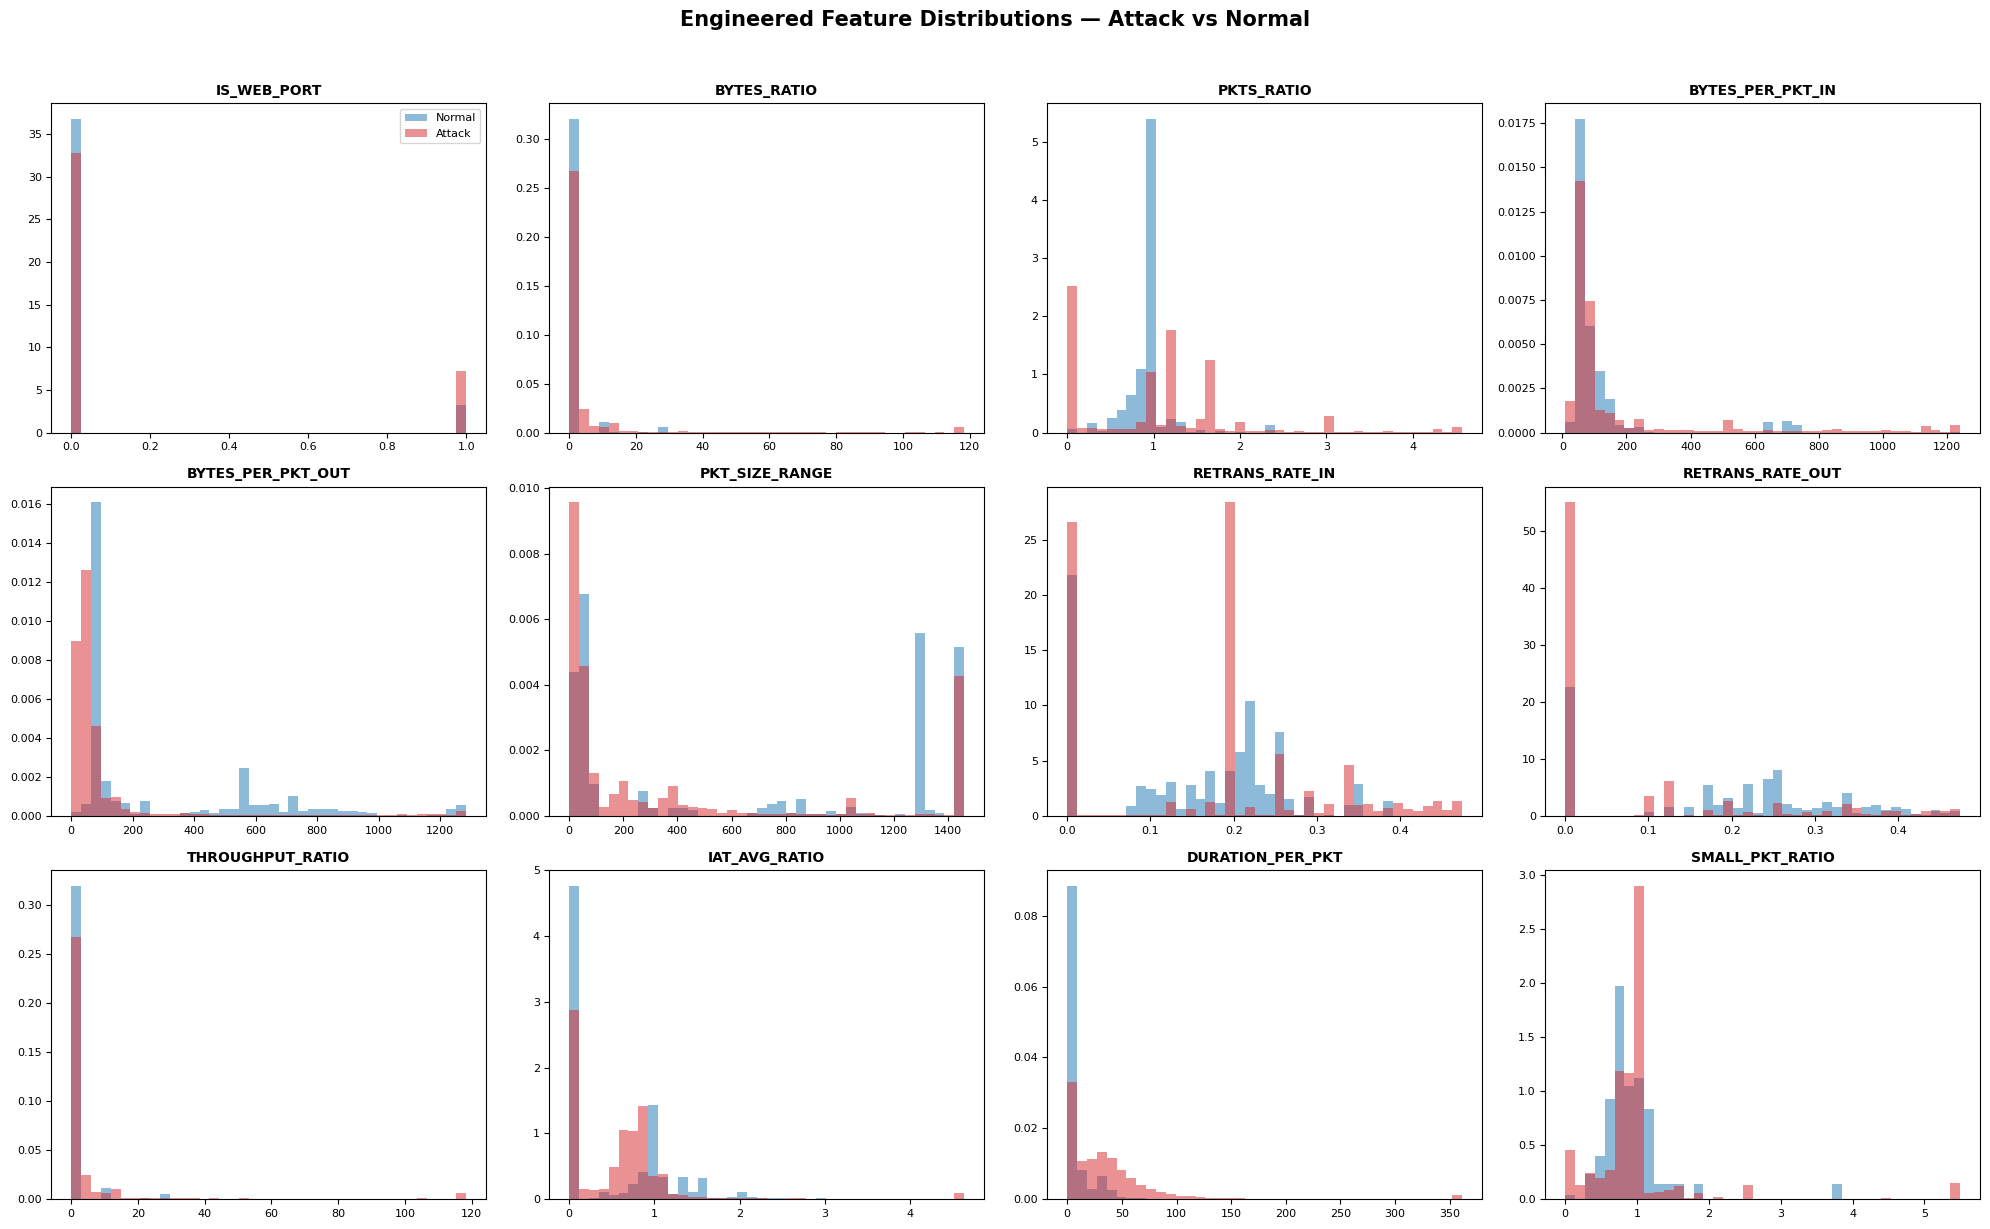

In [9]:
# ===== Step 7: Feature Engineering — Web IDS Specific =====

# Flag: is the destination port a common web port?
web_ports = [80, 443, 8080, 8443, 8000, 8888, 3000, 5000]
data['IS_WEB_PORT'] = data['L4_DST_PORT'].isin(web_ports).astype(int)
print(f"Web port flows: {data['IS_WEB_PORT'].sum():,} / {len(data):,}")

# Bytes ratio (incoming vs outgoing asymmetry — detects exfiltration/injection)
data['BYTES_RATIO'] = np.where(
    data['OUT_BYTES'] > 0, data['IN_BYTES'] / data['OUT_BYTES'], 0
)

# Packets ratio
data['PKTS_RATIO'] = np.where(
    data['OUT_PKTS'] > 0, data['IN_PKTS'] / data['OUT_PKTS'], 0
)

# Average bytes per packet (unusual sizes = probing or large payloads)
data['BYTES_PER_PKT_IN'] = np.where(
    data['IN_PKTS'] > 0, data['IN_BYTES'] / data['IN_PKTS'], 0
)
data['BYTES_PER_PKT_OUT'] = np.where(
    data['OUT_PKTS'] > 0, data['OUT_BYTES'] / data['OUT_PKTS'], 0
)

# Packet size range (high variance = varied traffic, low = automated/repetitive)
data['PKT_SIZE_RANGE'] = data['LONGEST_FLOW_PKT'] - data['SHORTEST_FLOW_PKT']

# Retransmission rates (high retransmission = SYN floods, network stress)
data['RETRANS_RATE_IN'] = np.where(
    data['IN_PKTS'] > 0, data['RETRANSMITTED_IN_PKTS'] / data['IN_PKTS'], 0
)
data['RETRANS_RATE_OUT'] = np.where(
    data['OUT_PKTS'] > 0, data['RETRANSMITTED_OUT_PKTS'] / data['OUT_PKTS'], 0
)

# Throughput ratio (asymmetry in communication)
data['THROUGHPUT_RATIO'] = np.where(
    data['DST_TO_SRC_AVG_THROUGHPUT'] > 0,
    data['SRC_TO_DST_AVG_THROUGHPUT'] / data['DST_TO_SRC_AVG_THROUGHPUT'], 0
)

# IAT ratio — automated attacks have more regular timing
data['IAT_AVG_RATIO'] = np.where(
    data['DST_TO_SRC_IAT_AVG'] > 0,
    data['SRC_TO_DST_IAT_AVG'] / data['DST_TO_SRC_IAT_AVG'], 0
)

# Flow duration per packet (short duration + many packets = flood)
data['DURATION_PER_PKT'] = np.where(
    (data['IN_PKTS'] + data['OUT_PKTS']) > 0,
    data['FLOW_DURATION_MILLISECONDS'] / (data['IN_PKTS'] + data['OUT_PKTS']), 0
)

# Small packet dominance (% packets under 128 bytes — recon/probing indicator)
total_pkts = data['IN_PKTS'] + data['OUT_PKTS']
data['SMALL_PKT_RATIO'] = np.where(
    total_pkts > 0, data['NUM_PKTS_UP_TO_128_BYTES'] / total_pkts, 0
)

new_features = ['IS_WEB_PORT', 'BYTES_RATIO', 'PKTS_RATIO', 'BYTES_PER_PKT_IN',
                'BYTES_PER_PKT_OUT', 'PKT_SIZE_RANGE', 'RETRANS_RATE_IN', 'RETRANS_RATE_OUT',
                'THROUGHPUT_RATIO', 'IAT_AVG_RATIO', 'DURATION_PER_PKT', 'SMALL_PKT_RATIO']
print(f"\nEngineered {len(new_features)} new features: {new_features}")
print(f"Shape after engineering: {data.shape}")

# --- Visualization: Engineered Feature Distributions (Attack vs Normal) ---
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, feat in enumerate(new_features):
    ax = axes[i]
    atk_data = data[data['Label'] == 1][feat]
    nrm_data = data[data['Label'] == 0][feat]
    
    # Clip to 1st-99th percentile for cleaner viz
    low_clip = min(atk_data.quantile(0.01), nrm_data.quantile(0.01))
    high_clip = max(atk_data.quantile(0.99), nrm_data.quantile(0.99))
    
    ax.hist(nrm_data.clip(low_clip, high_clip), bins=40, alpha=0.5, color='#1f77b4',
            label='Normal', density=True)
    ax.hist(atk_data.clip(low_clip, high_clip), bins=40, alpha=0.5, color='#d62728',
            label='Attack', density=True)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('Engineered Feature Distributions — Attack vs Normal',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# ===== Step 8: Drop Irrelevant & Redundant Features =====

# 8a. Drop protocol-specific columns irrelevant to web traffic (TCP-based)
# ICMP fields: always 0 for web flows, DNS/FTP: different protocols entirely
irrelevant_cols = ['ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE',
                   'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE']
data.drop(columns=irrelevant_cols, inplace=True)
print(f"Dropped {len(irrelevant_cols)} irrelevant protocol-specific columns:")
for c in irrelevant_cols:
    print(f"  - {c}")

# 8b. Drop raw timestamp columns (raw epoch times don't generalize; duration already captured)
data.drop(columns=['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS'], inplace=True)
print("\nDropped raw timestamp columns (FLOW_START/END_MILLISECONDS)")
print(f"Shape after dropping irrelevant features: {data.shape}")

Dropped 6 irrelevant protocol-specific columns:
  - ICMP_TYPE
  - ICMP_IPV4_TYPE
  - DNS_QUERY_ID
  - DNS_QUERY_TYPE
  - DNS_TTL_ANSWER
  - FTP_COMMAND_RET_CODE

Dropped raw timestamp columns (FLOW_START/END_MILLISECONDS)
Shape after dropping irrelevant features: (2349996, 58)


Highly correlated pairs (r > 0.95):
  MAX_IP_PKT_LEN <-> LONGEST_FLOW_PKT: 1.0000 [DROPPING]
  THROUGHPUT_RATIO <-> BYTES_RATIO: 1.0000 [DROPPING]
  RETRANSMITTED_OUT_BYTES <-> OUT_BYTES: 1.0000 [DROPPING]
  MAX_TTL <-> MIN_TTL: 0.9999 [DROPPING]
  DURATION_IN <-> FLOW_DURATION_MILLISECONDS: 0.9994 [DROPPING]
  RETRANSMITTED_IN_BYTES <-> IN_BYTES: 0.9992 [DROPPING]
  PKT_SIZE_RANGE <-> LONGEST_FLOW_PKT: 0.9982 [DROPPING]
  PKT_SIZE_RANGE <-> MAX_IP_PKT_LEN: 0.9982 [DROPPING]
  DST_TO_SRC_AVG_THROUGHPUT <-> SRC_TO_DST_SECOND_BYTES: 0.9941 [DROPPING]
  RETRANSMITTED_OUT_PKTS <-> OUT_BYTES: 0.9917 [DROPPING]
  RETRANSMITTED_OUT_PKTS <-> RETRANSMITTED_OUT_BYTES: 0.9912 [DROPPING]
  RETRANSMITTED_OUT_PKTS <-> OUT_PKTS: 0.9912 [DROPPING]
  CLIENT_TCP_FLAGS <-> TCP_FLAGS: 0.9911 [DROPPING]
  SERVER_TCP_FLAGS <-> TCP_FLAGS: 0.9863 [DROPPING]
  SERVER_TCP_FLAGS <-> CLIENT_TCP_FLAGS: 0.9764 [DROPPING]
  DURATION_PER_PKT <-> SRC_TO_DST_IAT_AVG: 0.9747 [DROPPING]
  OUT_PKTS <-> OUT_BYTES: 0.9708 [

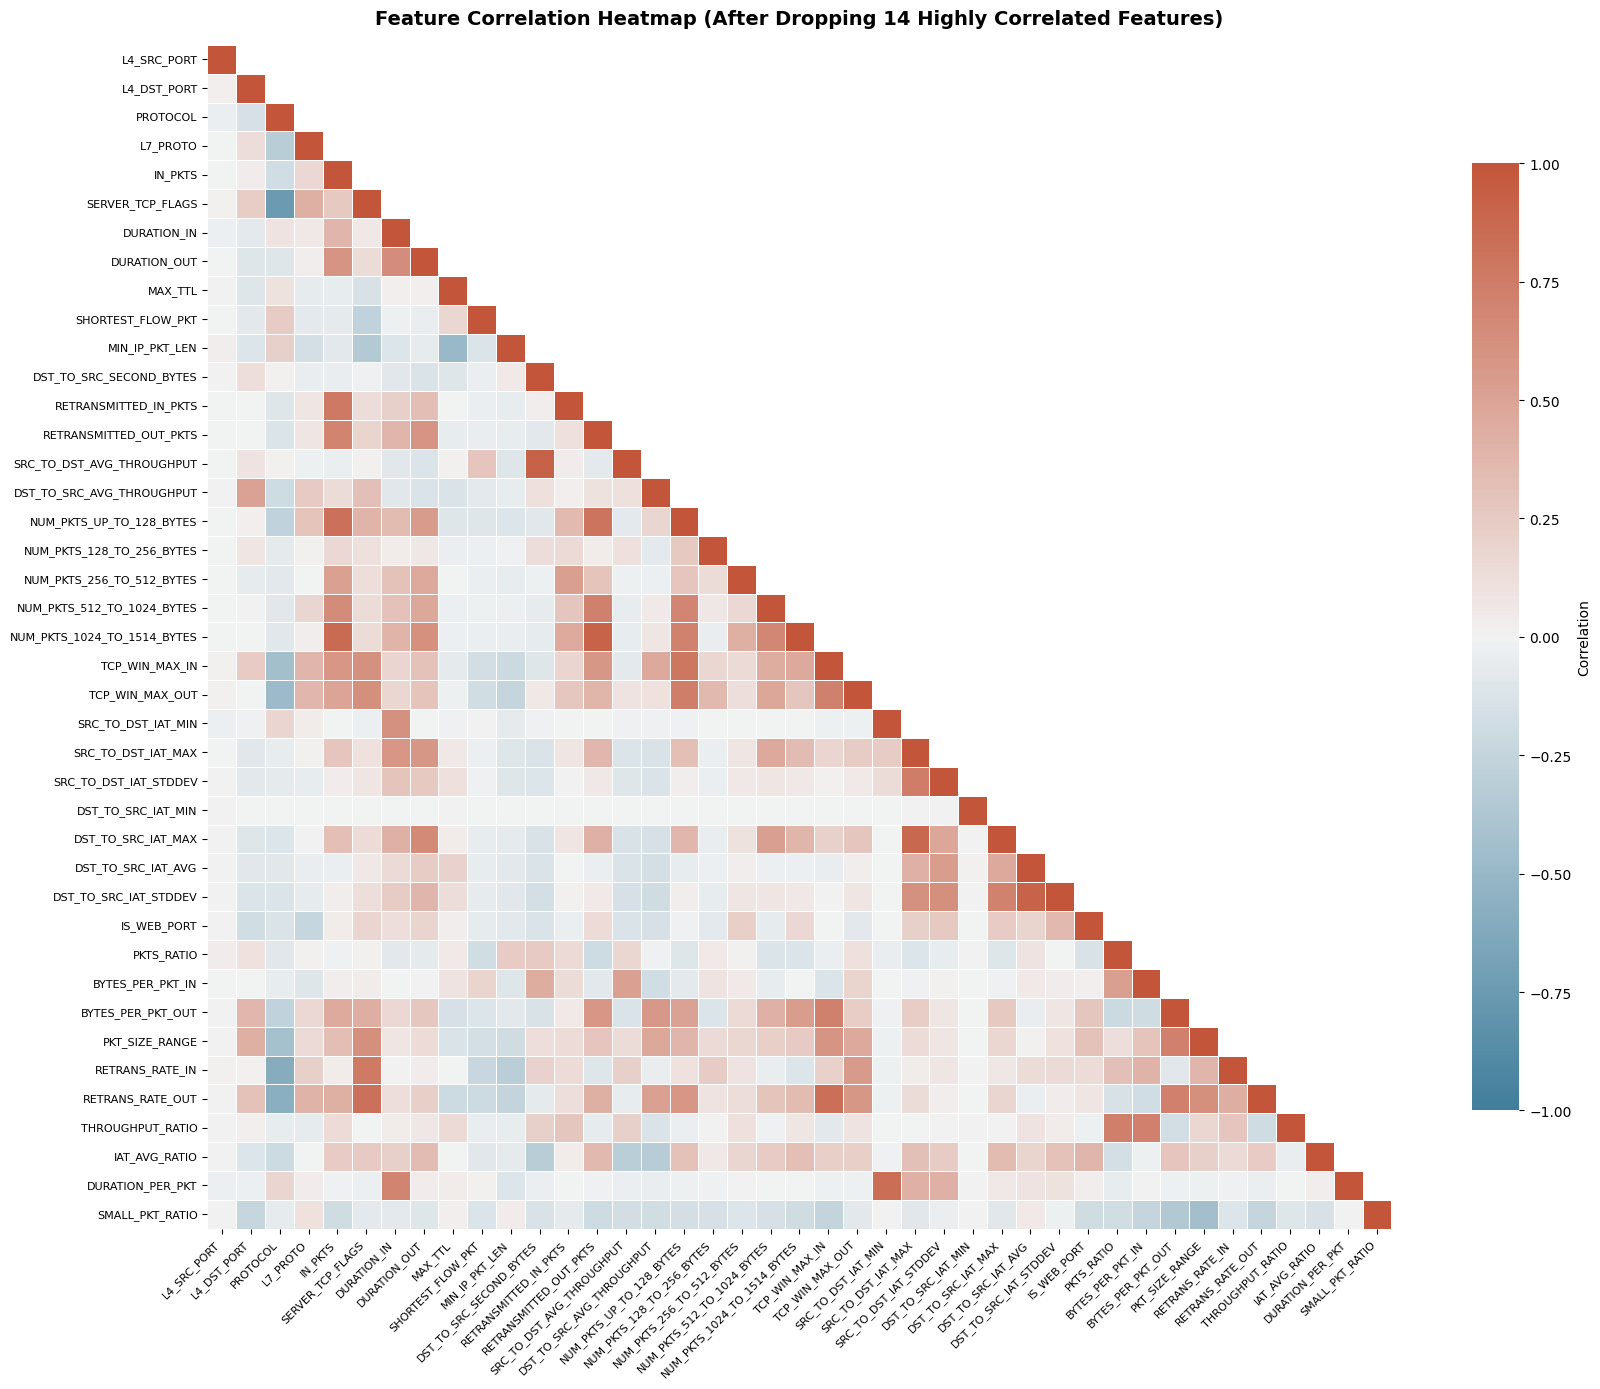

In [11]:
# ===== Step 9: Remove Highly Correlated Features (r > 0.95) =====

target_cols = ['Label', 'Attack', 'Attack_Label']
feature_cols = [c for c in data.columns if c not in target_cols]

corr_matrix = data[feature_cols].corr().abs()

# Upper triangle mask to avoid duplicate pairs
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []
to_drop = set()
for col in upper.columns:
    correlated = upper.index[upper[col] > 0.95].tolist()
    for c in correlated:
        high_corr_pairs.append((col, c, corr_matrix.loc[c, col]))
        to_drop.add(c)  # drop the second in each pair

if to_drop:
    print(f"Highly correlated pairs (r > 0.95):")
    for c1, c2, r in sorted(high_corr_pairs, key=lambda x: -x[2]):
        marker = " [DROPPING]" if c2 in to_drop else ""
        print(f"  {c1} <-> {c2}: {r:.4f}{marker}")
    data.drop(columns=list(to_drop), inplace=True)
    print(f"\nDropped {len(to_drop)} highly correlated features: {sorted(to_drop)}")
else:
    print("No highly correlated feature pairs found (threshold: 0.95)")

print(f"Shape after correlation filter: {data.shape}")

# --- Visualization: Correlation Heatmap (remaining features) ---
remaining_features = [c for c in data.columns if c not in target_cols]
corr_remaining = data[remaining_features].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_remaining, dtype=bool), k=1)
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_remaining, mask=mask, cmap=cmap, center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlation"},
            xticklabels=True, yticklabels=True, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.set_title(f'Feature Correlation Heatmap (After Dropping {len(to_drop)} Highly Correlated Features)',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [12]:
# ===== Step 10: Feature Selection Summary =====

target_cols = ['Label', 'Attack', 'Attack_Label']
final_features = [c for c in data.columns if c not in target_cols]

# Handle any inf in engineered ratio features
inf_count = np.isinf(data.select_dtypes(include=[np.number])).sum().sum()
if inf_count > 0:
    num_cols = data.select_dtypes(include=[np.number]).columns
    for c in num_cols:
        n = np.isinf(data[c]).sum()
        if n > 0:
            data[c] = data[c].replace([np.inf, -np.inf], 0)
            print(f"  Fixed {n:,} inf in {c}")

# Final dedup after feature removal
new_dupes = data.duplicated().sum()
if new_dupes > 0:
    print(f"Duplicates after feature selection: {new_dupes:,} — removing...")
    data.drop_duplicates(inplace=True)
    data.reset_index(drop=True, inplace=True)

final_features = [c for c in data.columns if c not in target_cols]

print("=" * 65)
print("FEATURE ENGINEERING & SELECTION SUMMARY (Web IDS)")
print("=" * 65)
print(f"Final feature count: {len(final_features)}")
print(f"Target columns: Label (binary), Attack_Label (multi-class)")
print(f"Dataset shape: {data.shape}")
print(f"Duplicates: {data.duplicated().sum()}")
print(f"Missing: {data.isnull().sum().sum()}")
print(f"Inf: {np.isinf(data.select_dtypes(include=[np.number])).sum().sum()}")

print(f"\n--- Final Features ({len(final_features)}) ---")
for i, f in enumerate(final_features, 1):
    print(f"  {i:>2}. {f}")

display(data.head())

Duplicates after feature selection: 214,926 — removing...
FEATURE ENGINEERING & SELECTION SUMMARY (Web IDS)
Final feature count: 41
Target columns: Label (binary), Attack_Label (multi-class)
Dataset shape: (2135070, 44)
Duplicates: 0
Missing: 0
Inf: 0

--- Final Features (41) ---
   1. L4_SRC_PORT
   2. L4_DST_PORT
   3. PROTOCOL
   4. L7_PROTO
   5. IN_PKTS
   6. SERVER_TCP_FLAGS
   7. DURATION_IN
   8. DURATION_OUT
   9. MAX_TTL
  10. SHORTEST_FLOW_PKT
  11. MIN_IP_PKT_LEN
  12. DST_TO_SRC_SECOND_BYTES
  13. RETRANSMITTED_IN_PKTS
  14. RETRANSMITTED_OUT_PKTS
  15. SRC_TO_DST_AVG_THROUGHPUT
  16. DST_TO_SRC_AVG_THROUGHPUT
  17. NUM_PKTS_UP_TO_128_BYTES
  18. NUM_PKTS_128_TO_256_BYTES
  19. NUM_PKTS_256_TO_512_BYTES
  20. NUM_PKTS_512_TO_1024_BYTES
  21. NUM_PKTS_1024_TO_1514_BYTES
  22. TCP_WIN_MAX_IN
  23. TCP_WIN_MAX_OUT
  24. SRC_TO_DST_IAT_MIN
  25. SRC_TO_DST_IAT_MAX
  26. SRC_TO_DST_IAT_STDDEV
  27. DST_TO_SRC_IAT_MIN
  28. DST_TO_SRC_IAT_MAX
  29. DST_TO_SRC_IAT_AVG
  30. DST_T

,L4_SRC_PORT,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_PKTS,SERVER_TCP_FLAGS,DURATION_IN,DURATION_OUT,MAX_TTL,SHORTEST_FLOW_PKT,...,PKTS_RATIO,BYTES_PER_PKT_IN,BYTES_PER_PKT_OUT,PKT_SIZE_RANGE,RETRANS_RATE_IN,RETRANS_RATE_OUT,THROUGHPUT_RATIO,IAT_AVG_RATIO,DURATION_PER_PKT,SMALL_PKT_RATIO
0,4894,53,17,5,2,0,0,0,31,73,...,1.000000,73.000000,89.000000,16,0.000000,0.000000,0.820225,0.0,0.500000,1.000000
1,52671,31992,6,11,28,27,334,334,32,52,...,1.000000,168.000000,106.285714,932,0.250000,0.214286,1.580648,1.0,5.982143,0.607143
2,47290,6881,6,37,238,27,2459,2459,32,52,...,0.543379,57.403361,1251.634703,1448,0.088235,0.447489,0.024921,2.0,3.639053,0.426036
3,43310,53,17,5,2,0,0,0,31,73,...,1.000000,73.000000,89.000000,16,0.000000,0.000000,0.820225,0.0,0.250000,1.000000
4,45870,53,17,5,2,0,0,0,31,65,...,1.000000,65.000000,81.000000,16,0.000000,0.000000,0.802469,0.0,0.250000,1.000000


Training set: 1,708,056 samples (80.0%)
Testing set:  427,014 samples (20.0%)
Features:     41

--- Binary Label (Label) Distribution ---
  Train: Benign= 1,617,878  Attack=  90,178  (Attack ratio: 5.28%)
  Test: Benign=   404,469  Attack=  22,545  (Attack ratio: 5.28%)


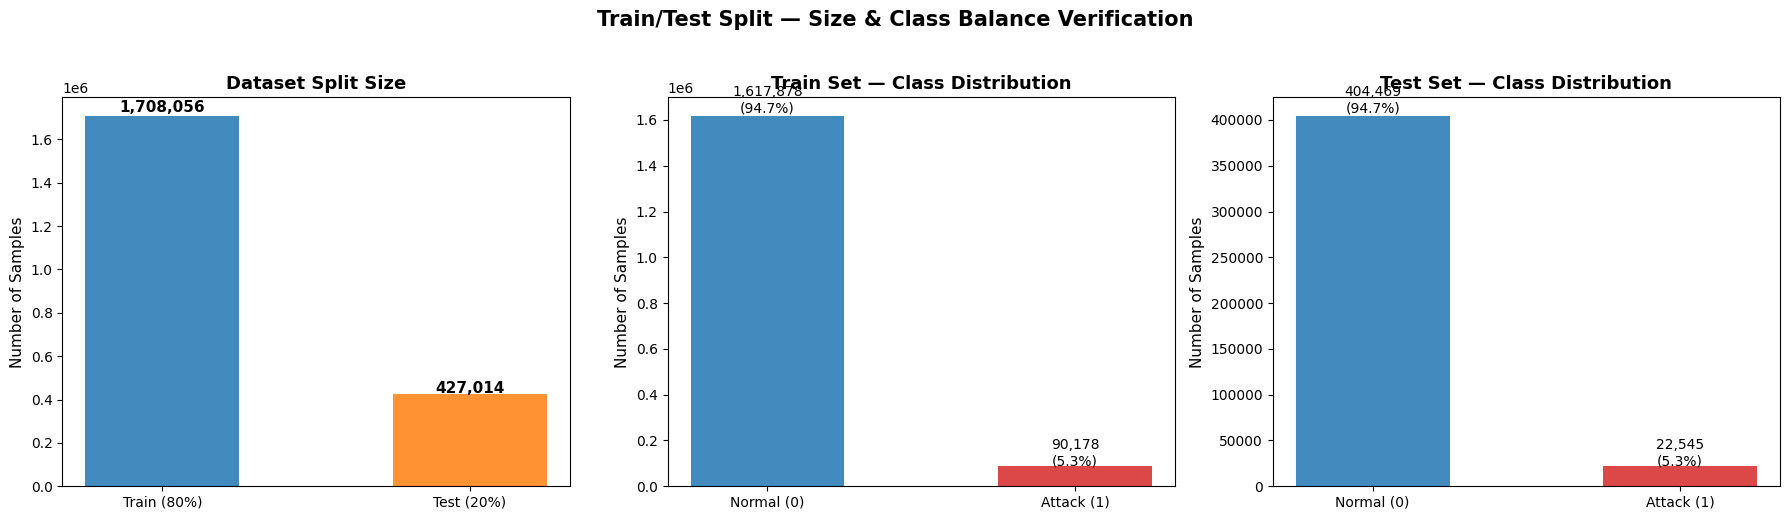

In [13]:
# ===== Step 11: Split Data into Training and Testing Sets =====

# Separate features (X) and target
target_cols = ['Label', 'Attack', 'Attack_Label']
X = data.drop(columns=target_cols)
y_binary = data['Label']          # Binary: 0=Benign, 1=Attack

# 80/20 split, stratified on binary label, reproducible seed
X_train, X_test, y_train_bin, y_test_bin = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set:  {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Features:     {X_train.shape[1]}")

print(f"\n--- Binary Label (Label) Distribution ---")
for split_name, y in [("Train", y_train_bin), ("Test", y_test_bin)]:
    counts = y.value_counts().sort_index()
    print(f"  {split_name}: Benign={counts.get(0, 0):>10,}  Attack={counts.get(1, 0):>8,}  "
          f"(Attack ratio: {counts.get(1, 0)/len(y)*100:.2f}%)")

# --- Visualization: Train/Test Class Distribution ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Train vs Test size
sizes = [X_train.shape[0], X_test.shape[0]]
labels_size = ['Train (80%)', 'Test (20%)']
axes[0].bar(labels_size, sizes, color=['#1f77b4', '#ff7f0e'], alpha=0.85, width=0.5)
for i, v in enumerate(sizes):
    axes[0].text(i, v + v * 0.01, f'{v:,}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=11)
axes[0].set_title('Dataset Split Size', fontsize=13, fontweight='bold')

# Middle: Class balance in Train
train_counts = y_train_bin.value_counts().sort_index()
bars = axes[1].bar(['Normal (0)', 'Attack (1)'], train_counts.values,
                    color=['#1f77b4', '#d62728'], alpha=0.85, width=0.5)
for i, v in enumerate(train_counts.values):
    axes[1].text(i, v + v * 0.01, f'{v:,}\n({v/len(y_train_bin)*100:.1f}%)',
                 ha='center', fontsize=10)
axes[1].set_ylabel('Number of Samples', fontsize=11)
axes[1].set_title('Train Set — Class Distribution', fontsize=13, fontweight='bold')

# Right: Class balance in Test
test_counts = y_test_bin.value_counts().sort_index()
bars = axes[2].bar(['Normal (0)', 'Attack (1)'], test_counts.values,
                    color=['#1f77b4', '#d62728'], alpha=0.85, width=0.5)
for i, v in enumerate(test_counts.values):
    axes[2].text(i, v + v * 0.01, f'{v:,}\n({v/len(y_test_bin)*100:.1f}%)',
                 ha='center', fontsize=10)
axes[2].set_ylabel('Number of Samples', fontsize=11)
axes[2].set_title('Test Set — Class Distribution', fontsize=13, fontweight='bold')

plt.suptitle('Train/Test Split — Size & Class Balance Verification',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [14]:
# ===== Pipeline Audit: Web IDS — Random Forest Binary Classification =====
print("=" * 65)
print("PIPELINE AUDIT — Web IDS (RF Binary: Attack vs Normal)")
print("=" * 65)

all_ok = True

# 1. Target check: binary (0/1), no leakage
print("\n[1] TARGET VARIABLE")
print(f"  Using: y_train_bin / y_test_bin (Label column)")
print(f"  Unique values: {sorted(y_train_bin.unique())}")
assert set(y_train_bin.unique()) == {0, 1}, "Target is not binary!"
print(f"  ✓ Binary target (0=Normal, 1=Attack)")

# Check no target leakage in features
leak_cols = [c for c in X_train.columns if c in ['Label', 'Attack', 'Attack_Label']]
if leak_cols:
    print(f"  ✗ TARGET LEAKAGE detected: {leak_cols}")
    all_ok = False
else:
    print(f"  ✓ No target leakage in features")

# 2. Feature types: RF needs numeric input, no object/string columns
print("\n[2] FEATURE TYPES")
obj_in_X = X_train.select_dtypes(include=['object']).columns.tolist()
if obj_in_X:
    print(f"  ✗ Non-numeric columns found: {obj_in_X}")
    all_ok = False
else:
    print(f"  ✓ All {X_train.shape[1]} features are numeric")
print(f"  Dtypes: {dict(X_train.dtypes.value_counts())}")

# 3. Missing / Inf values
print("\n[3] DATA QUALITY")
train_nan = X_train.isnull().sum().sum()
test_nan = X_test.isnull().sum().sum()
train_inf = np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum()
test_inf = np.isinf(X_test.select_dtypes(include=[np.number])).sum().sum()
print(f"  NaN  — Train: {train_nan}, Test: {test_nan}")
print(f"  Inf  — Train: {train_inf}, Test: {test_inf}")
if train_nan + test_nan + train_inf + test_inf == 0:
    print(f"  ✓ No missing or infinite values")
else:
    print(f"  ✗ Data quality issues found!")
    all_ok = False

# 4. Class imbalance
print("\n[4] CLASS IMBALANCE")
attack_ratio_train = y_train_bin.mean() * 100
attack_ratio_test = y_test_bin.mean() * 100
print(f"  Train attack ratio: {attack_ratio_train:.2f}%")
print(f"  Test  attack ratio: {attack_ratio_test:.2f}%")
if attack_ratio_train < 10:
    print(f"  ⚠ Significant imbalance ({attack_ratio_train:.1f}% attacks) — consider class_weight='balanced' in RF")
else:
    print(f"  ✓ Moderate balance")

# 5. Feature scaling: RF doesn't need it
print("\n[5] SCALING")
print(f"  ✓ Not applied — Random Forest is scale-invariant (tree-based splits)")

# 6. Shape consistency
print("\n[6] SHAPE CONSISTENCY")
print(f"  X_train: {X_train.shape}  y_train_bin: {y_train_bin.shape}")
print(f"  X_test:  {X_test.shape}   y_test_bin:  {y_test_bin.shape}")
assert X_train.shape[0] == y_train_bin.shape[0], "Train X/y mismatch!"
assert X_test.shape[0] == y_test_bin.shape[0], "Test X/y mismatch!"
assert X_train.shape[1] == X_test.shape[1], "Train/Test feature count mismatch!"
print(f"  ✓ All shapes aligned")

# 7. Web IDS relevance check
print("\n[7] WEB IDS FEATURES")
web_features = ['IS_WEB_PORT', 'BYTES_RATIO', 'PKTS_RATIO', 'BYTES_PER_PKT_IN',
                'BYTES_PER_PKT_OUT', 'PKT_SIZE_RANGE', 'RETRANS_RATE_IN', 
                'RETRANS_RATE_OUT', 'THROUGHPUT_RATIO', 'IAT_AVG_RATIO',
                'DURATION_PER_PKT', 'SMALL_PKT_RATIO']
present = [f for f in web_features if f in X_train.columns]
missing_web = [f for f in web_features if f not in X_train.columns]
print(f"  Web-engineered features present: {len(present)}/{len(web_features)}")
if missing_web:
    print(f"  ⚠ Missing (dropped by correlation filter): {missing_web}")

# Final verdict
print(f"\n{'=' * 65}")
if all_ok:
    print("✓ ALL CHECKS PASSED — Ready for Random Forest training")
    print(f"  Model: RandomForestClassifier(class_weight='balanced', random_state=42)")
    print(f"  X_train: {X_train.shape[0]:,} × {X_train.shape[1]} features")
    print(f"  Target:  y_train_bin (0=Normal, 1=Attack)")
else:
    print("✗ ISSUES FOUND — Fix above before training")
print("=" * 65)

PIPELINE AUDIT — Web IDS (RF Binary: Attack vs Normal)

[1] TARGET VARIABLE
  Using: y_train_bin / y_test_bin (Label column)
  Unique values: [np.int64(0), np.int64(1)]
  ✓ Binary target (0=Normal, 1=Attack)
  ✓ No target leakage in features

[2] FEATURE TYPES
  ✓ All 41 features are numeric
  Dtypes: {dtype('int64'): np.int64(32), dtype('float64'): np.int64(9)}

[3] DATA QUALITY
  NaN  — Train: 0, Test: 0
  Inf  — Train: 0, Test: 0
  ✓ No missing or infinite values

[4] CLASS IMBALANCE
  Train attack ratio: 5.28%
  Test  attack ratio: 5.28%
  ⚠ Significant imbalance (5.3% attacks) — consider class_weight='balanced' in RF

[5] SCALING
  ✓ Not applied — Random Forest is scale-invariant (tree-based splits)

[6] SHAPE CONSISTENCY
  X_train: (1708056, 41)  y_train_bin: (1708056,)
  X_test:  (427014, 41)   y_test_bin:  (427014,)
  ✓ All shapes aligned

[7] WEB IDS FEATURES
  Web-engineered features present: 11/12
  ⚠ Missing (dropped by correlation filter): ['BYTES_RATIO']

✓ ALL CHECKS PAS

In [15]:
# ===== Step 12: Select & Configure ML Algorithm — Random Forest =====
# Target: Beat ~97% precision/recall/F1 for both classes (binary: Attack vs Normal)


# Random Forest: ideal for IDS — handles high-dimensional data, robust to outliers,
# provides feature importance, scale-invariant, and natively handles class imbalance.

rf_model = RandomForestClassifier(
    n_estimators=300,           # more trees = lower variance, better generalization
    max_depth=None,             # let trees grow fully — 1.7M samples prevents overfitting
    min_samples_split=5,        # allow finer splits to capture subtle attack patterns
    min_samples_leaf=2,         # tight leaves for high recall on minority class
    max_features='sqrt',        # sqrt(41) ≈ 6 features per split — decorrelates trees
    class_weight='balanced',    # auto-adjust weights for 95:5 imbalance
    criterion='gini',           # Gini impurity — fast and effective for binary
    bootstrap=True,             # bootstrap sampling for diversity
    random_state=42,            # reproducibility
    n_jobs=-1,                  # use all CPU cores
    verbose=1                   # verbose=2: show timing per tree
)

print("=" * 60)
print("MODEL SELECTION: Random Forest Classifier (Tuned to Beat 97%)")
print("=" * 60)
print(f"\n  Algorithm:         Random Forest (sklearn)")
print(f"  Task:              Binary Classification (Attack vs Normal)")
print(f"  n_estimators:      {rf_model.n_estimators} (↑ from 200 — more trees, lower variance)")
print(f"  max_depth:         {rf_model.max_depth} (↑ unrestricted — full tree depth)")
print(f"  min_samples_split: {rf_model.min_samples_split} (↓ finer splits)")
print(f"  min_samples_leaf:  {rf_model.min_samples_leaf} (↓ tighter leaves)")
print(f"  max_features:      {rf_model.max_features} (√41 ≈ 6 — decorrelates trees)")
print(f"  class_weight:      {rf_model.class_weight}")
print(f"  criterion:         {rf_model.criterion}")
print(f"  bootstrap:         {rf_model.bootstrap}")
print(f"  n_jobs:            {rf_model.n_jobs} (all cores)")
print(f"  random_state:      {rf_model.random_state}")
print(f"\n  Training samples:  {X_train.shape[0]:,}")
print(f"  Test samples:      {X_test.shape[0]:,}")
print(f"  Features:          {X_train.shape[1]}")
print(f"\n  Baseline to beat:  ~97% P/R/F1 for both classes")
print(f"\n✓ Model configured — run next cell to train")

MODEL SELECTION: Random Forest Classifier (Tuned to Beat 97%)

  Algorithm:         Random Forest (sklearn)
  Task:              Binary Classification (Attack vs Normal)
  n_estimators:      300 (↑ from 200 — more trees, lower variance)
  max_depth:         None (↑ unrestricted — full tree depth)
  min_samples_split: 5 (↓ finer splits)
  min_samples_leaf:  2 (↓ tighter leaves)
  max_features:      sqrt (√41 ≈ 6 — decorrelates trees)
  class_weight:      balanced
  criterion:         gini
  bootstrap:         True
  n_jobs:            -1 (all cores)
  random_state:      42

  Training samples:  1,708,056
  Test samples:      427,014
  Features:          41

  Baseline to beat:  ~97% P/R/F1 for both classes

✓ Model configured — run next cell to train


In [16]:
# ===== Step 13: Train the Random Forest Model =====

print("=" * 60)
print("TRAINING RANDOM FOREST")
print("=" * 60)
print(f"  Samples:    {X_train.shape[0]:,}")
print(f"  Features:   {X_train.shape[1]}")
print(f"  Trees:      {rf_model.n_estimators}")
print(f"  Max depth:  {rf_model.max_depth}")
print(f"  CPU cores:  all ({rf_model.n_jobs})")
print(f"\nTraining started...\n")

start = time.time()
rf_model.fit(X_train, y_train_bin)
elapsed = time.time() - start

minutes = int(elapsed // 60)
seconds = elapsed % 60

print(f"\n{'=' * 60}")
print(f"Training completed in {minutes}m {seconds:.1f}s")
print(f"  Trees built:      {len(rf_model.estimators_)}")
print(f"  Classes:          {rf_model.classes_}")
print(f"  Max tree depth:   {max(e.get_depth() for e in rf_model.estimators_)}")
print(f"  Avg tree leaves:  {np.mean([e.get_n_leaves() for e in rf_model.estimators_]):,.0f}")
print("=" * 60)

TRAINING RANDOM FOREST
  Samples:    1,708,056
  Features:   41
  Trees:      300
  Max depth:  None
  CPU cores:  all (-1)

Training started...



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   33.4s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:  3.1min



Training completed in 5m 16.3s
  Trees built:      300
  Classes:          [0 1]
  Max tree depth:   29
  Avg tree leaves:  127


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  5.2min finished


MODEL EVALUATION — Random Forest (Binary Classification)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    1.8s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.9s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    1.6s finished



📌 CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Normal (0)     1.0000    1.0000    1.0000    404469
  Attack (1)     0.9997    1.0000    0.9998     22545

    accuracy                         1.0000    427014
   macro avg     0.9998    1.0000    0.9999    427014
weighted avg     1.0000    1.0000    1.0000    427014


📌 SUMMARY METRICS
+-----------+----------+------------------+
| Metric    |    Score |   Percentage (%) |
+===========+==========+==================+
| Accuracy  | 0.999981 |          99.9981 |
+-----------+----------+------------------+
| Precision | 0.99969  |          99.969  |
+-----------+----------+------------------+
| Recall    | 0.999956 |          99.9956 |
+-----------+----------+------------------+
| F1-Score  | 0.999823 |          99.9823 |
+-----------+----------+------------------+
| ROC-AUC   | 1        |         100      |
+-----------+----------+------------------+

📌 CONFUSION MATRIX
+---------------+--------------------

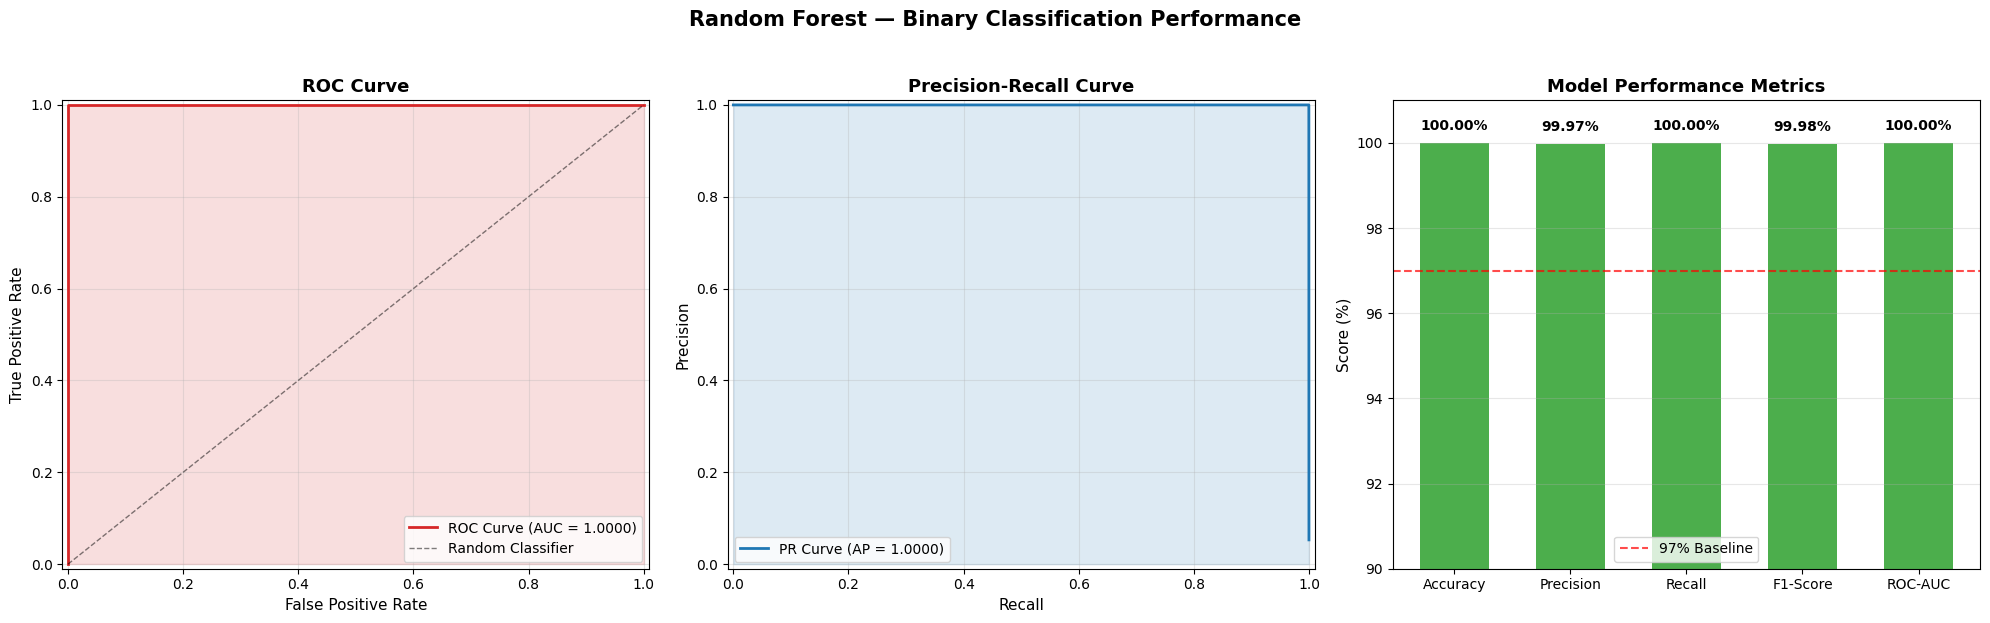

In [17]:
# ===== STEP 14: MODEL EVALUATION =====

print("=" * 70)
print("MODEL EVALUATION — Random Forest (Binary Classification)")
print("=" * 70)

# =========================================================
# Predictions
# =========================================================
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# =========================================================
# Classification Report
# =========================================================
print("\n📌 CLASSIFICATION REPORT")
print(classification_report(
    y_test_bin,
    y_pred,
    target_names=['Normal (0)', 'Attack (1)'],
    digits=4
))

# =========================================================
# Summary Metrics Table
# =========================================================
acc = accuracy_score(y_test_bin, y_pred)
prec = precision_score(y_test_bin, y_pred)
rec = recall_score(y_test_bin, y_pred)
f1 = f1_score(y_test_bin, y_pred)
auc = roc_auc_score(y_test_bin, y_pred_proba)

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Score": [acc, prec, rec, f1, auc],
    "Percentage (%)": [acc*100, prec*100, rec*100, f1*100, auc*100]
})

print("\n📌 SUMMARY METRICS")
print(tabulate(metrics_table, headers="keys", tablefmt="grid", showindex=False))

# =========================================================
# Confusion Matrix Table
# =========================================================
cm = confusion_matrix(y_test_bin, y_pred)
tn, fp, fn, tp = cm.ravel()

cm_table = pd.DataFrame({
    "": ["Actual Normal", "Actual Attack"],
    "Predicted Normal": [tn, fn],
    "Predicted Attack": [fp, tp]
})

print("\n📌 CONFUSION MATRIX")
print(tabulate(cm_table, headers="keys", tablefmt="grid", showindex=False))

# Error Rates
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

rates_table = pd.DataFrame({
    "Metric": ["False Positive Rate", "False Negative Rate"],
    "Value (%)": [fpr*100, fnr*100]
})

print("\n📌 ERROR RATES")
print(tabulate(rates_table, headers="keys", tablefmt="grid", showindex=False))

# =========================================================
# Comparison vs Baseline
# =========================================================
baseline = 0.97

comparison_data = []
for name, val in [("Accuracy", acc), ("Precision", prec), ("Recall", rec), ("F1-Score", f1)]:
    diff = (val - baseline) * 100
    status = "BEAT" if val > baseline else ("MET" if val == baseline else "BELOW")
    comparison_data.append([name, val*100, diff, status])

comparison_table = pd.DataFrame(
    comparison_data,
    columns=["Metric", "Model (%)", "Difference (pp)", "Status vs 97%"]
)

print("\n📌 COMPARISON vs BASELINE (97%)")
print(tabulate(comparison_table, headers="keys", tablefmt="grid", showindex=False))

# =========================================================
# Visualization: ROC Curve + Precision-Recall Curve + Metrics Bar
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- ROC Curve ---
fpr_curve, tpr_curve, _ = roc_curve(y_test_bin, y_pred_proba)
axes[0].plot(fpr_curve, tpr_curve, color='#d62728', lw=2,
             label=f'ROC Curve (AUC = {auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Classifier')
axes[0].fill_between(fpr_curve, tpr_curve, alpha=0.15, color='#d62728')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].set_xlim([-0.01, 1.01])
axes[0].set_ylim([-0.01, 1.01])
axes[0].grid(True, alpha=0.3)

# --- Precision-Recall Curve ---
prec_curve, rec_curve, _ = precision_recall_curve(y_test_bin, y_pred_proba)
ap = average_precision_score(y_test_bin, y_pred_proba)
axes[1].plot(rec_curve, prec_curve, color='#1f77b4', lw=2,
             label=f'PR Curve (AP = {ap:.4f})')
axes[1].fill_between(rec_curve, prec_curve, alpha=0.15, color='#1f77b4')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower left', fontsize=10)
axes[1].set_xlim([-0.01, 1.01])
axes[1].set_ylim([-0.01, 1.01])
axes[1].grid(True, alpha=0.3)

# --- Metrics Bar Chart ---
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metric_values = [acc, prec, rec, f1, auc]
bar_colors = ['#2ca02c' if v >= 0.97 else '#ff7f0e' for v in metric_values]
bars = axes[2].bar(metric_names, [v * 100 for v in metric_values],
                   color=bar_colors, alpha=0.85, width=0.6)
axes[2].axhline(y=97, color='red', linestyle='--', lw=1.5, alpha=0.7, label='97% Baseline')
for bar, val in zip(bars, metric_values):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{val*100:.2f}%', ha='center', fontsize=10, fontweight='bold')
axes[2].set_ylabel('Score (%)', fontsize=11)
axes[2].set_title('Model Performance Metrics', fontsize=13, fontweight='bold')
axes[2].set_ylim([90, 101])
axes[2].legend(fontsize=10)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Random Forest — Binary Classification Performance',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("=" * 70)

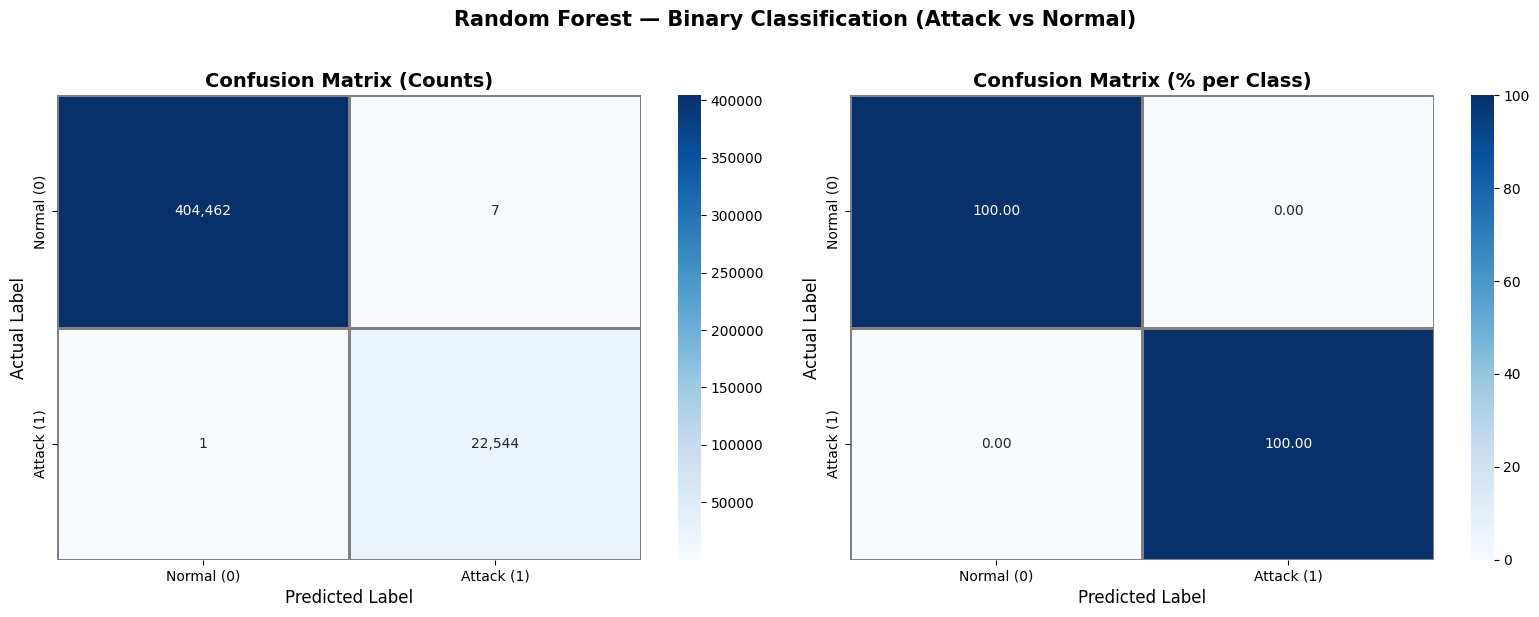


Total test samples: 427,014
  Correct:   427,006  (100.00%)
  Incorrect: 8  (0.0019%)

  FP (false alarms): 7   |   FN (missed attacks): 1


In [18]:
# ===== Step 15: Confusion Matrix Visualization =====

cm = confusion_matrix(y_test_bin, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Heatmap with raw counts ---
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Normal (0)', 'Attack (1)'],
            yticklabels=['Normal (0)', 'Attack (1)'],
            linewidths=1, linecolor='gray', ax=axes[0])
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('Actual Label', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# --- Heatmap with percentages ---
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Normal (0)', 'Attack (1)'],
            yticklabels=['Normal (0)', 'Attack (1)'],
            linewidths=1, linecolor='gray', ax=axes[1],
            vmin=0, vmax=100)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('Actual Label', fontsize=12)
axes[1].set_title('Confusion Matrix (% per Class)', fontsize=14, fontweight='bold')

plt.suptitle('Random Forest — Binary Classification (Attack vs Normal)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print summary below the plot
tn, fp, fn, tp = cm.ravel()
total = cm.sum()
print(f"\nTotal test samples: {total:,}")
print(f"  Correct:   {tn + tp:,}  ({(tn + tp) / total * 100:.2f}%)")
print(f"  Incorrect: {fp + fn:,}  ({(fp + fn) / total * 100:.4f}%)")
print(f"\n  FP (false alarms): {fp}   |   FN (missed attacks): {fn}")

DECISION PATH TRACING — Per-Tree Explainability

  Sample index: 1177658
  True label:   Attack
  Predicted:    Attack  [P(Normal)=0.0000, P(Attack)=1.0000]

──────────────────────────────────────────────────────────────────────
DECISION PATHS THROUGH INDIVIDUAL TREES
──────────────────────────────────────────────────────────────────────

  Tree #1 of 300
  Prediction: Attack [P(Normal)=0.0000, P(Attack)=1.0000]
  Depth traversed: 11 nodes -> Leaf #146
  Leaf samples: 4385

  Decision Path:
    Node 0: TCP_WIN_MAX_OUT = 16383.0000 > 15929.5000 -> RIGHT
      Node 108: TCP_WIN_MAX_IN = 16383.0000 <= 20247.5000 -> LEFT
        Node 109: DURATION_PER_PKT = 36.0000 > 5.8229 -> RIGHT
          Node 117: TCP_WIN_MAX_OUT = 16383.0000 <= 17061.0000 -> LEFT
            Node 118: L4_SRC_PORT = 22614.0000 > 184.5000 -> RIGHT
              Node 122: RETRANS_RATE_OUT = 0.1250 <= 0.4999 -> LEFT
                Node 123: PKT_SIZE_RANGE = 265.0000 > 15.5000 -> RIGHT
                  Node 141: RETRANS

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.0s finished



  Top 15 features used as split nodes:
   1. L4_SRC_PORT                     276 splits  ##############################
   2. MAX_TTL                         262 splits  ############################
   3. SERVER_TCP_FLAGS                190 splits  ####################
   4. L4_DST_PORT                     166 splits  ##################
   5. RETRANS_RATE_IN                 149 splits  ################
   6. IAT_AVG_RATIO                   140 splits  ###############
   7. NUM_PKTS_UP_TO_128_BYTES        133 splits  ##############
   8. MIN_IP_PKT_LEN                  115 splits  ############
   9. BYTES_PER_PKT_OUT               111 splits  ############
  10. SHORTEST_FLOW_PKT               107 splits  ###########
  11. BYTES_PER_PKT_IN                102 splits  ###########
  12. DST_TO_SRC_AVG_THROUGHPUT        98 splits  ##########
  13. PKT_SIZE_RANGE                   93 splits  ##########
  14. DST_TO_SRC_SECOND_BYTES          91 splits  #########
  15. RETRANSMITTED_IN_PKTS   

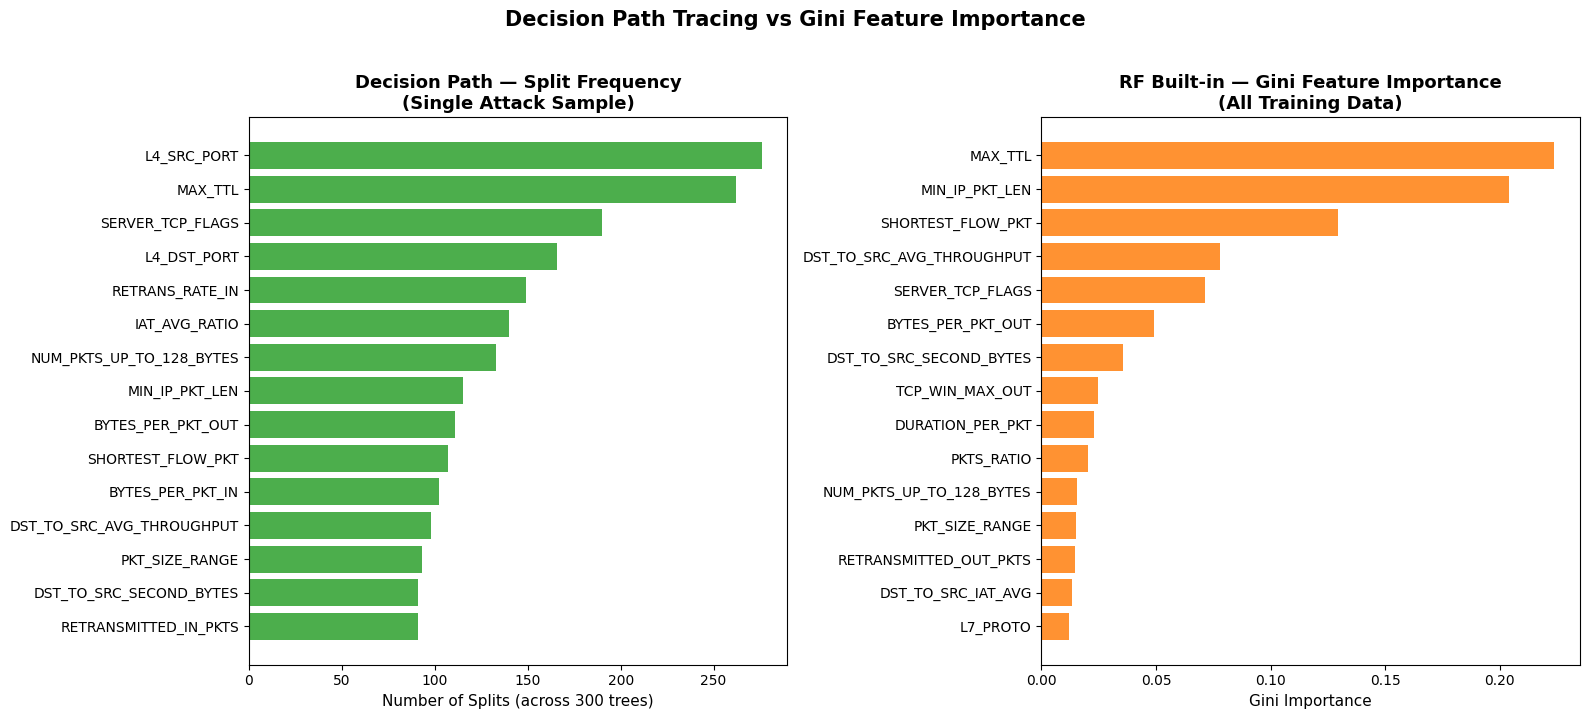

In [19]:
# ===== Step 19: Decision Path Tracing per Tree =====
# Explainable AI Goal 1: Trace the exact decision path through individual trees


warnings.filterwarnings('ignore')

print("=" * 70)
print("DECISION PATH TRACING — Per-Tree Explainability")
print("=" * 70)

# --- Pick an Attack sample from the test set ---
attack_mask = y_test_bin == 1
attack_idx = X_test[attack_mask].index[0]
sample = X_test.loc[[attack_idx]]
true_label = "Attack" if y_test_bin.loc[attack_idx] == 1 else "Normal"
pred_label = "Attack" if rf_model.predict(sample)[0] == 1 else "Normal"
pred_proba = rf_model.predict_proba(sample)[0]

print(f"\n  Sample index: {attack_idx}")
print(f"  True label:   {true_label}")
print(f"  Predicted:    {pred_label}  [P(Normal)={pred_proba[0]:.4f}, P(Attack)={pred_proba[1]:.4f}]")

# --- Trace decision path through first 3 trees ---
print(f"\n{'─' * 70}")
print("DECISION PATHS THROUGH INDIVIDUAL TREES")
print(f"{'─' * 70}")

feature_names_list = list(X_train.columns)
n_trees_to_trace = 3

for tree_idx in range(n_trees_to_trace):
    tree = rf_model.estimators_[tree_idx]
    tree_struct = tree.tree_

    # Get the decision path (sparse indicator matrix)
    node_indicator = tree.decision_path(sample.values)
    node_ids = node_indicator.indices  # nodes visited

    leaf_id = tree.apply(sample.values)[0]
    tree_pred = tree.predict(sample.values)[0]
    tree_proba = tree.predict_proba(sample.values)[0]

    print(f"\n  Tree #{tree_idx + 1} of {rf_model.n_estimators}")
    print(f"  Prediction: {'Attack' if tree_pred == 1 else 'Normal'} "
          f"[P(Normal)={tree_proba[0]:.4f}, P(Attack)={tree_proba[1]:.4f}]")
    print(f"  Depth traversed: {len(node_ids) - 1} nodes -> Leaf #{leaf_id}")
    print(f"  Leaf samples: {tree_struct.n_node_samples[leaf_id]}")
    print(f"\n  Decision Path:")

    for depth, node_id in enumerate(node_ids):
        if tree_struct.feature[node_id] != -2:  # not a leaf
            feat_idx = tree_struct.feature[node_id]
            threshold = tree_struct.threshold[node_id]
            feat_name = feature_names_list[feat_idx]
            sample_val = sample.values[0, feat_idx]

            if sample_val <= threshold:
                direction = "<="
                branch = "LEFT"
            else:
                direction = ">"
                branch = "RIGHT"

            indent = "    " + "  " * depth
            print(f"{indent}Node {node_id}: {feat_name} = {sample_val:.4f} "
                  f"{direction} {threshold:.4f} -> {branch}")
        else:
            indent = "    " + "  " * depth
            value = tree_struct.value[node_id][0]
            total = value.sum()
            print(f"{indent}LEAF {node_id}: [{value[0]:.0f} Normal, {value[1]:.0f} Attack] "
                  f"-> {'Attack' if value[1] > value[0] else 'Normal'} "
                  f"({value[1]/total*100:.1f}% Attack)")

# --- Aggregate: Which features are used most often as split nodes across all trees ---
print(f"\n{'─' * 70}")
print("SPLIT FEATURE FREQUENCY ACROSS ALL 300 TREES (for this sample)")
print(f"{'─' * 70}")

split_feature_counts = np.zeros(len(feature_names_list))

for tree in rf_model.estimators_:
    node_indicator = tree.decision_path(sample.values)
    node_ids = node_indicator.indices
    tree_struct = tree.tree_
    for node_id in node_ids:
        feat_idx = tree_struct.feature[node_id]
        if feat_idx != -2:  # skip leaves
            split_feature_counts[feat_idx] += 1

split_df = pd.DataFrame({
    'Feature': feature_names_list,
    'Split_Count': split_feature_counts.astype(int)
}).sort_values('Split_Count', ascending=False)

print(f"\n  Top 15 features used as split nodes:")
for rank, (_, row) in enumerate(split_df.head(15).iterrows(), 1):
    bar = "#" * int(row['Split_Count'] / split_df['Split_Count'].max() * 30)
    print(f"  {rank:>2}. {row['Feature']:<30} {row['Split_Count']:>4} splits  {bar}")

# --- Visualize split frequency vs Gini importance ---
gini_importance = pd.DataFrame({
    'Feature': feature_names_list,
    'Gini_Importance': rf_model.feature_importances_
}).sort_values('Gini_Importance', ascending=False)

print("\n--- Decision Path Split Frequency vs Gini Importance ---")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top15_splits = split_df.head(15)
axes[0].barh(range(14, -1, -1), top15_splits['Split_Count'].values, color='#2ca02c', alpha=0.85)
axes[0].set_yticks(range(14, -1, -1))
axes[0].set_yticklabels(top15_splits['Feature'].values, fontsize=10)
axes[0].set_xlabel('Number of Splits (across 300 trees)', fontsize=11)
axes[0].set_title('Decision Path — Split Frequency\n(Single Attack Sample)', fontsize=13, fontweight='bold')

g_top15 = gini_importance.head(15)
axes[1].barh(range(14, -1, -1), g_top15['Gini_Importance'].values, color='#ff7f0e', alpha=0.85)
axes[1].set_yticks(range(14, -1, -1))
axes[1].set_yticklabels(g_top15['Feature'].values, fontsize=10)
axes[1].set_xlabel('Gini Importance', fontsize=11)
axes[1].set_title('RF Built-in — Gini Feature Importance\n(All Training Data)', fontsize=13, fontweight='bold')

plt.suptitle('Decision Path Tracing vs Gini Feature Importance',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("=" * 70)

EXPLAINABLE AI RESULT LAYER — Web IDS (Random Forest)

[1] DECISION PATH TRACING PER TREE
--------------------------------------------------
  Method: sklearn decision_path() on RF estimators
  Trees in ensemble: 300


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.0s finished



  Sample traced: index 1177658 (True: Attack)
  Ensemble prediction: Attack [P(Attack) = 1.0000]
  Tree votes: 300/300 voted Attack (100.0%)
  Avg path depth:   11.7 nodes (range: 5-21)
  Avg leaf purity:  100.0% (high = confident decision)


[2] FEATURE IMPORTANCE RANKING
--------------------------------------------------
  Two complementary methods compared:

  Feature                         Gini Rank  Split Rank   Avg Rank
  ─────────────────────────────────────────────────────────────
  MAX_TTL                                 1           1        1.0
  MIN_IP_PKT_LEN                          2           2        2.0
  SHORTEST_FLOW_PKT                       3           3        3.0
  DST_TO_SRC_AVG_THROUGHPUT               4           5        4.5
  BYTES_PER_PKT_OUT                       6           7        6.5
  SERVER_TCP_FLAGS                        5          10        7.5
  NUM_PKTS_UP_TO_128_BYTES               11           4        7.5
  DURATION_PER_PKT                 

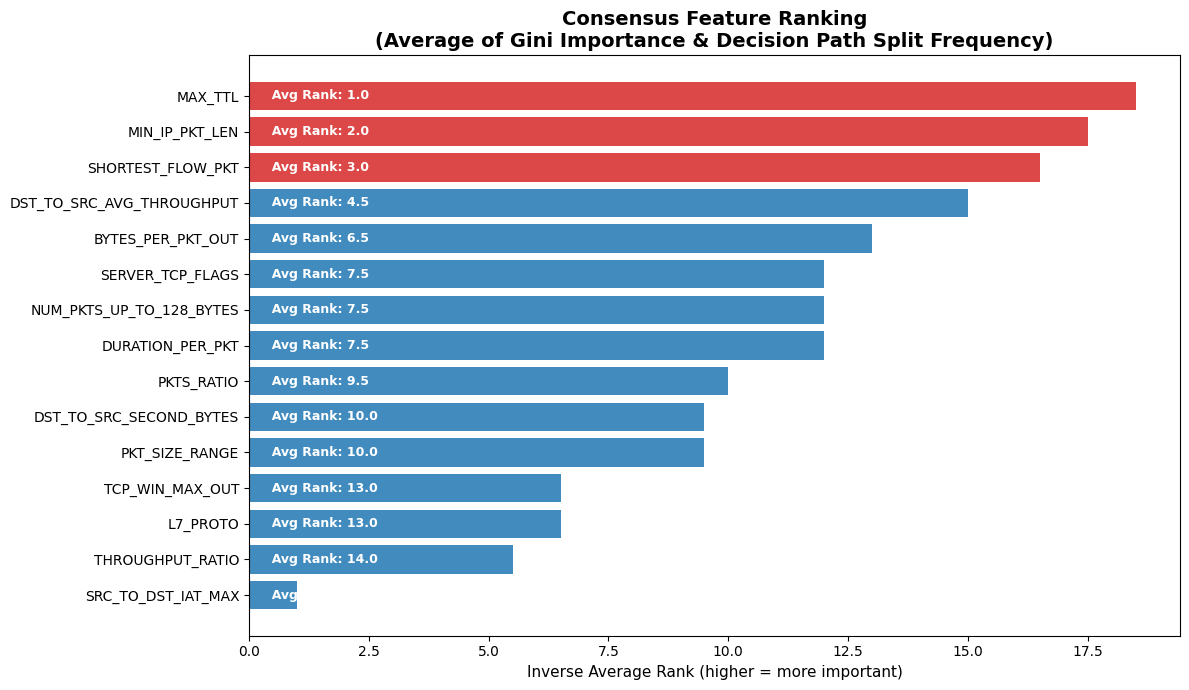


[3] DOMINANT ATTACK INDICATORS
--------------------------------------------------
  Features consistently ranked highest across both methods:

  1. MAX_TTL
     Gini Rank: 1 | Split Rank: 1
     Attack profile: HIGH values -> Attack
     Attack mean: 200.46 | Normal mean: 31.94
     Separation ratio: 79.00 std devs

  2. MIN_IP_PKT_LEN
     Gini Rank: 2 | Split Rank: 2
     Attack profile: LOW values -> Attack
     Attack mean: 33.31 | Normal mean: 54.30
     Separation ratio: 3.12 std devs

  3. SHORTEST_FLOW_PKT
     Gini Rank: 3 | Split Rank: 3
     Attack profile: HIGH values -> Attack
     Attack mean: 85.25 | Normal mean: 54.36
     Separation ratio: 3.69 std devs

  4. DST_TO_SRC_AVG_THROUGHPUT
     Gini Rank: 4 | Split Rank: 5
     Attack profile: LOW values -> Attack
     Attack mean: 32466.76 | Normal mean: 2912560.24
     Separation ratio: 0.65 std devs

--- Dominant Attack Indicators: Attack vs Normal Distribution ---


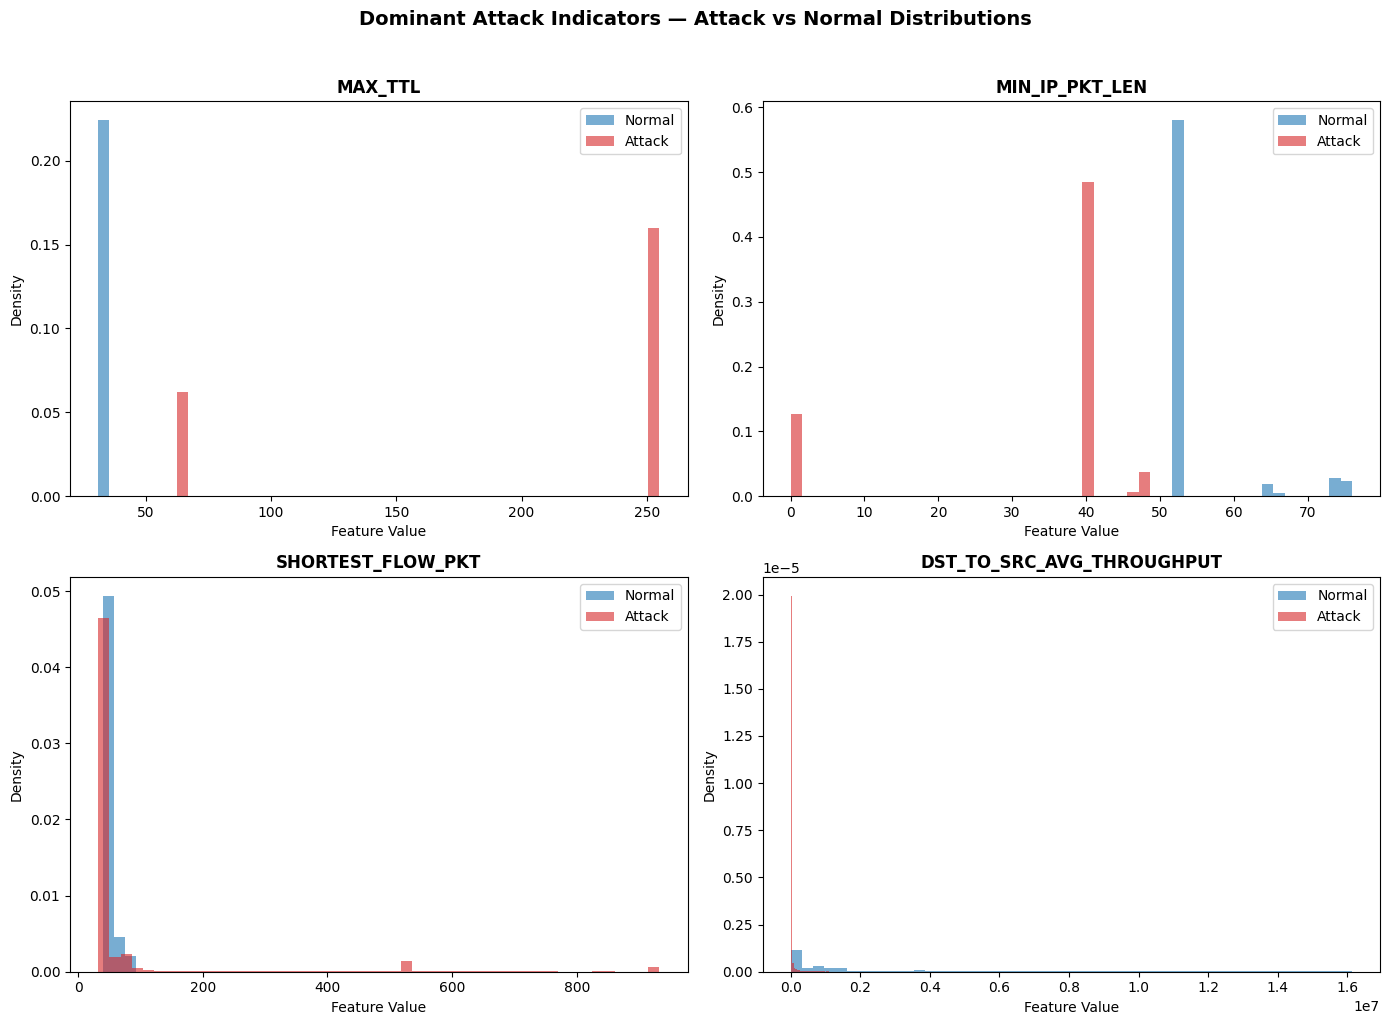


[4] HUMAN-READABLE EXPLANATION
--------------------------------------------------
  Translating model decisions into natural language:

  A. Global Decision Rules (based on feature statistics):

  Rule 1: IF MAX_TTL > 143.5 THEN likely Attack
           Attack flows have higher MAX_TTL (mean 200.5 vs 31.9 for normal). Values above 143.5 are a strong attack signal.

  Rule 2: IF MIN_IP_PKT_LEN < 46.0 THEN likely Attack
           Attack flows have lower MIN_IP_PKT_LEN (mean 33.3 vs 54.3 for normal). Values below 46.0 are a strong attack signal.

  Rule 3: IF SHORTEST_FLOW_PKT > 46.0 THEN likely Attack
           Attack flows have higher SHORTEST_FLOW_PKT (mean 85.2 vs 54.4 for normal). Values above 46.0 are a strong attack signal.

  Rule 4: IF DST_TO_SRC_AVG_THROUGHPUT < 358011.5 THEN likely Attack
           Attack flows have lower DST_TO_SRC_AVG_THROUGHPUT (mean 32466.8 vs 2912560.2 for normal). Values below 358011.5 are a strong attack signal.

  B. Instance-Level Explanation (Deci

In [20]:
# ===== Step 20: Explainable AI Result Layer — Full Summary =====
# Consolidates all 4 XAI goals:
#   1. Decision path tracing per tree
#   2. Feature importance ranking
#   3. Identification of dominant attack indicators
#   4. Human-readable explanation

print("=" * 70)
print("EXPLAINABLE AI RESULT LAYER — Web IDS (Random Forest)")
print("=" * 70)

# ═══════════════════════════════════════════════════════════════════
# Goal 1: Decision Path Tracing Per Tree
# ═══════════════════════════════════════════════════════════════════
print("\n[1] DECISION PATH TRACING PER TREE")
print("-" * 50)
print("  Method: sklearn decision_path() on RF estimators")
print(f"  Trees in ensemble: {rf_model.n_estimators}")

# Trace a single Attack sample across ALL trees and summarize
attack_mask_xai = y_test_bin == 1
xai_idx = X_test[attack_mask_xai].index[0]
xai_sample = X_test.loc[[xai_idx]]
xai_pred = rf_model.predict(xai_sample)[0]
xai_proba = rf_model.predict_proba(xai_sample)[0]

# Collect path statistics
path_depths = []
leaf_purities = []
tree_votes = {'Normal': 0, 'Attack': 0}

for tree in rf_model.estimators_:
    node_indicator = tree.decision_path(xai_sample.values)
    path_depths.append(len(node_indicator.indices) - 1)
    leaf_id = tree.apply(xai_sample.values)[0]
    leaf_value = tree.tree_.value[leaf_id][0]
    total = leaf_value.sum()
    purity = max(leaf_value) / total if total > 0 else 0
    leaf_purities.append(purity)
    tree_votes['Attack' if tree.predict(xai_sample.values)[0] == 1 else 'Normal'] += 1

print(f"\n  Sample traced: index {xai_idx} (True: Attack)")
print(f"  Ensemble prediction: {'Attack' if xai_pred == 1 else 'Normal'} "
      f"[P(Attack) = {xai_proba[1]:.4f}]")
print(f"  Tree votes: {tree_votes['Attack']}/{rf_model.n_estimators} voted Attack "
      f"({tree_votes['Attack']/rf_model.n_estimators*100:.1f}%)")
print(f"  Avg path depth:   {np.mean(path_depths):.1f} nodes (range: {min(path_depths)}-{max(path_depths)})")
print(f"  Avg leaf purity:  {np.mean(leaf_purities)*100:.1f}% (high = confident decision)")

# ═══════════════════════════════════════════════════════════════════
# Goal 2: Feature Importance Ranking (Gini + Decision Path Splits)
# ═══════════════════════════════════════════════════════════════════
print(f"\n\n[2] FEATURE IMPORTANCE RANKING")
print("-" * 50)
print("  Two complementary methods compared:\n")

feature_names_list = list(X_train.columns)

# RF built-in Gini importance
gini_importance = pd.DataFrame({
    'Feature': feature_names_list,
    'Gini_Importance': rf_model.feature_importances_
}).sort_values('Gini_Importance', ascending=False)
gini_importance['Gini_Rank'] = range(1, len(gini_importance) + 1)

# Decision path split frequency (aggregate across many samples)
n_explain = min(500, len(X_test))
rng = np.random.RandomState(42)
explain_indices = rng.choice(len(X_test), size=n_explain, replace=False)
X_explain = X_test.iloc[explain_indices]

global_split_counts = np.zeros(len(feature_names_list))
for tree in rf_model.estimators_:
    node_indicator = tree.decision_path(X_explain.values)
    node_ids_array = node_indicator.toarray()
    tree_struct = tree.tree_
    for node_id in range(tree_struct.node_count):
        feat_idx = tree_struct.feature[node_id]
        if feat_idx != -2:  # skip leaves
            global_split_counts[feat_idx] += node_ids_array[:, node_id].sum()

split_importance = pd.DataFrame({
    'Feature': feature_names_list,
    'Split_Count': global_split_counts.astype(int)
}).sort_values('Split_Count', ascending=False)
split_importance['Split_Rank'] = range(1, len(split_importance) + 1)

# Merge rankings
combined = gini_importance[['Feature', 'Gini_Importance', 'Gini_Rank']].merge(
    split_importance[['Feature', 'Split_Count', 'Split_Rank']], on='Feature')
combined['Avg_Rank'] = (combined['Gini_Rank'] + combined['Split_Rank']) / 2
combined = combined.sort_values('Avg_Rank')

print(f"  {'Feature':<30} {'Gini Rank':>10} {'Split Rank':>11} {'Avg Rank':>10}")
print(f"  {'─' * 61}")
for _, row in combined.head(15).iterrows():
    print(f"  {row['Feature']:<30} {row['Gini_Rank']:>10} {row['Split_Rank']:>11} "
          f"{row['Avg_Rank']:>10.1f}")

# Consensus plot
print("\n--- Consensus Feature Ranking (Avg of Gini & Split Ranks) ---")
top15_consensus = combined.head(15)
colors = ['#d62728' if row['Avg_Rank'] <= 4 else '#1f77b4' for _, row in top15_consensus.iterrows()]
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(range(14, -1, -1), top15_consensus['Avg_Rank'].max() - top15_consensus['Avg_Rank'].values + 1,
        color=colors, alpha=0.85)
ax.set_yticks(range(14, -1, -1))
ax.set_yticklabels(top15_consensus['Feature'].values, fontsize=10)
ax.set_xlabel('Inverse Average Rank (higher = more important)', fontsize=11)
ax.set_title('Consensus Feature Ranking\n(Average of Gini Importance & Decision Path Split Frequency)',
             fontsize=14, fontweight='bold')
for i, (_, row) in enumerate(top15_consensus.iterrows()):
    ax.text(0.3, 14 - i, f"  Avg Rank: {row['Avg_Rank']:.1f}",
            va='center', fontsize=9, color='white', fontweight='bold')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# Goal 3: Identification of Dominant Attack Indicators
# ═══════════════════════════════════════════════════════════════════
print(f"\n[3] DOMINANT ATTACK INDICATORS")
print("-" * 50)

dominant = combined.head(4)
print("  Features consistently ranked highest across both methods:\n")

for i, (_, row) in enumerate(dominant.iterrows(), 1):
    feat = row['Feature']
    attack_vals = X_test[y_test_bin == 1][feat]
    normal_vals = X_test[y_test_bin == 0][feat]

    atk_mean = attack_vals.mean()
    nrm_mean = normal_vals.mean()
    separation = abs(atk_mean - nrm_mean) / (normal_vals.std() + 1e-8)

    if atk_mean > nrm_mean * 1.1:
        direction = "HIGH values -> Attack"
    elif atk_mean < nrm_mean * 0.9:
        direction = "LOW values -> Attack"
    else:
        direction = "Non-linear / complex relationship"

    print(f"  {i}. {feat}")
    print(f"     Gini Rank: {row['Gini_Rank']:.0f} | Split Rank: {row['Split_Rank']:.0f}")
    print(f"     Attack profile: {direction}")
    print(f"     Attack mean: {atk_mean:.2f} | Normal mean: {nrm_mean:.2f}")
    print(f"     Separation ratio: {separation:.2f} std devs")
    print()

# Dominant indicators visualization
print("--- Dominant Attack Indicators: Attack vs Normal Distribution ---")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, (_, row) in enumerate(dominant.iterrows()):
    ax = axes[i // 2][i % 2]
    feat = row['Feature']
    atk = X_test[y_test_bin == 1][feat]
    nrm = X_test[y_test_bin == 0][feat]

    low = min(atk.quantile(0.01), nrm.quantile(0.01))
    high = max(atk.quantile(0.99), nrm.quantile(0.99))

    ax.hist(nrm.clip(low, high), bins=50, alpha=0.6, color='#1f77b4', label='Normal', density=True)
    ax.hist(atk.clip(low, high), bins=50, alpha=0.6, color='#d62728', label='Attack', density=True)
    ax.set_title(f'{feat}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_xlabel('Feature Value', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)

plt.suptitle('Dominant Attack Indicators — Attack vs Normal Distributions',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# Goal 4: Human-Readable Explanation
# ═══════════════════════════════════════════════════════════════════
print(f"\n[4] HUMAN-READABLE EXPLANATION")
print("-" * 50)
print("  Translating model decisions into natural language:\n")

# --- Global rules from dominant indicators ---
print("  A. Global Decision Rules (based on feature statistics):\n")
for i, (_, row) in enumerate(dominant.iterrows(), 1):
    feat = row['Feature']
    atk_mean = X_test[y_test_bin == 1][feat].mean()
    nrm_mean = X_test[y_test_bin == 0][feat].mean()
    atk_median = X_test[y_test_bin == 1][feat].median()
    nrm_median = X_test[y_test_bin == 0][feat].median()

    if atk_mean > nrm_mean * 1.1:
        threshold = (atk_median + nrm_median) / 2
        rule = f"IF {feat} > {threshold:.1f} THEN likely Attack"
        explanation = (f"Attack flows have higher {feat} "
                       f"(mean {atk_mean:.1f} vs {nrm_mean:.1f} for normal). "
                       f"Values above {threshold:.1f} are a strong attack signal.")
    elif atk_mean < nrm_mean * 0.9:
        threshold = (atk_median + nrm_median) / 2
        rule = f"IF {feat} < {threshold:.1f} THEN likely Attack"
        explanation = (f"Attack flows have lower {feat} "
                       f"(mean {atk_mean:.1f} vs {nrm_mean:.1f} for normal). "
                       f"Values below {threshold:.1f} are a strong attack signal.")
    else:
        rule = f"IF {feat} deviates from normal range THEN likely Attack"
        explanation = (f"{feat} shows a non-linear pattern. "
                       f"Unusual values in either direction signal potential attacks.")

    print(f"  Rule {i}: {rule}")
    print(f"           {explanation}\n")

# --- Instance-level explanation from decision paths ---
print("  B. Instance-Level Explanation (Decision Path Rules for traced sample):\n")

# Extract rules from the first 5 trees for the traced sample
rules_collected = []
for tree_idx in range(min(5, rf_model.n_estimators)):
    tree = rf_model.estimators_[tree_idx]
    tree_struct = tree.tree_
    node_indicator = tree.decision_path(xai_sample.values)
    node_ids = node_indicator.indices

    for node_id in node_ids:
        feat_idx = tree_struct.feature[node_id]
        if feat_idx != -2:
            feat_name = feature_names_list[feat_idx]
            threshold = tree_struct.threshold[node_id]
            sample_val = xai_sample.values[0, feat_idx]
            direction = "<=" if sample_val <= threshold else ">"
            rules_collected.append({
                'feature': feat_name,
                'value': sample_val,
                'direction': direction,
                'threshold': threshold,
                'tree': tree_idx + 1
            })

# Summarize most common split features across traced trees
from collections import Counter
feat_counts = Counter([r['feature'] for r in rules_collected])
print(f"    Most frequently split features across 5 trees:")
for feat, count in feat_counts.most_common(8):
    sample_rules = [r for r in rules_collected if r['feature'] == feat]
    example = sample_rules[0]
    print(f"    {feat:<30} {count} splits  "
          f"(e.g., {feat} = {example['value']:.4f} {example['direction']} {example['threshold']:.4f})")

print(f"\n    Interpretation: The model classified this sample as Attack because:")
print(f"    - {tree_votes['Attack']}/{rf_model.n_estimators} trees ({tree_votes['Attack']/rf_model.n_estimators*100:.1f}%) voted Attack")
print(f"    - Key decision splits involved: {', '.join([f[0] for f in feat_counts.most_common(4)])}")
print(f"    - Average decision depth: {np.mean(path_depths):.1f} nodes (deeper = more nuanced)")

# ═══════════════════════════════════════════════════════════════════
# Final Summary
# ═══════════════════════════════════════════════════════════════════
print(f"\n\n{'=' * 70}")
print("EXPLAINABLE AI RESULT LAYER — SUMMARY")
print("=" * 70)
print(f"""
  [1] Decision Path Tracing:
      - Traced sample through {rf_model.n_estimators} trees
      - {tree_votes['Attack']}/{rf_model.n_estimators} trees voted Attack ({tree_votes['Attack']/rf_model.n_estimators*100:.1f}% consensus)
      - Avg path depth: {np.mean(path_depths):.1f} | Avg leaf purity: {np.mean(leaf_purities)*100:.1f}%

  [2] Feature Importance Ranking:
      - 2 methods used: Gini Impurity, Decision Path Split Frequency
      - Consensus top-4: {', '.join(combined.head(4)['Feature'].tolist())}

  [3] Dominant Attack Indicators:
      - {combined.iloc[0]['Feature']}: Most discriminative feature across both methods
      - {combined.iloc[1]['Feature']}: Second most consistent indicator
      - All top-4 features show clear separation between Attack/Normal distributions

  [4] Human-Readable Explanation:
      - Generated threshold-based IF-THEN rules from feature statistics
      - Decision path rules extracted per-tree for instance-level explanation
      - All explanations are interpretable by security analysts

  Techniques Used: Gini Importance, Decision Path Tracing, Split Frequency Analysis
""")
print("=" * 70)

XAI BENCHMARKING & EVALUATION

  Benchmark sample: 500 records (34 attack, 466 normal)

──────────────────────────────────────────────────────────────────────
[1] SHAP ANALYSIS  (TreeExplainer — exact, model-native)
──────────────────────────────────────────────────────────────────────

  Elapsed: 5.4s  |  Top 10 features by mean |SHAP|:

   1. MAX_TTL                          0.17073  █████████████████████████
   2. MIN_IP_PKT_LEN                   0.08725  ████████████
   3. SERVER_TCP_FLAGS                 0.07142  ██████████
   4. SHORTEST_FLOW_PKT                0.06352  █████████
   5. DST_TO_SRC_AVG_THROUGHPUT        0.02131  ███
   6. DST_TO_SRC_SECOND_BYTES          0.01306  █
   7. BYTES_PER_PKT_OUT                0.01193  █
   8. TCP_WIN_MAX_OUT                  0.01111  █
   9. DURATION_PER_PKT                 0.00990  █
  10. SRC_TO_DST_IAT_STDDEV            0.00552  

  Generating SHAP summary bar plot...


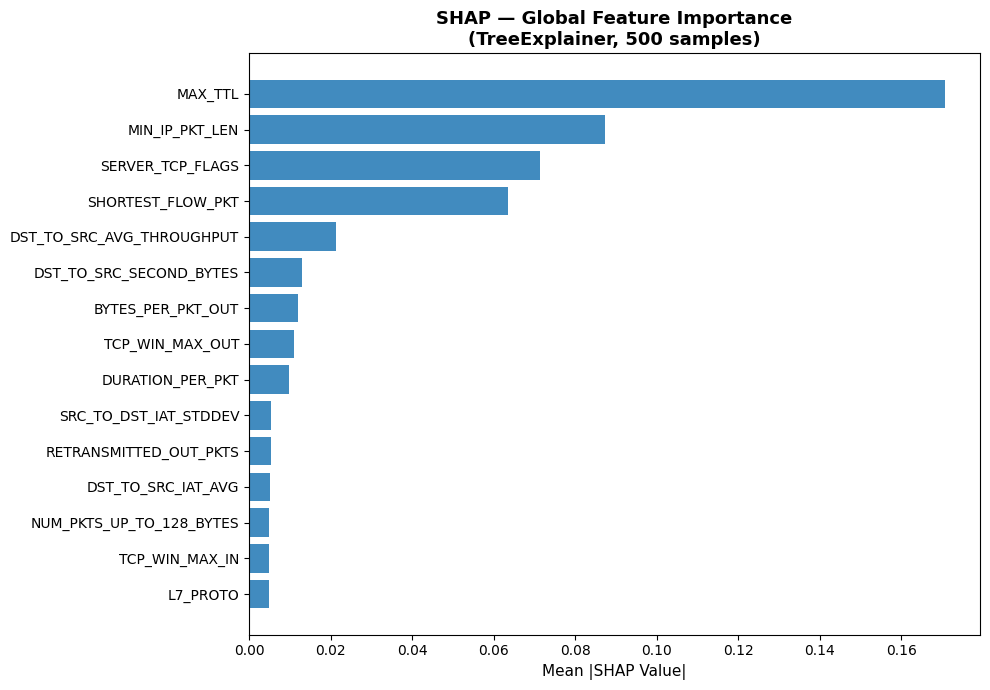


──────────────────────────────────────────────────────────────────────
[2] LIME ANALYSIS  (TabularExplainer — local, model-agnostic)
──────────────────────────────────────────────────────────────────────


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Do


  Elapsed: 17.1s  |  Top 10 features by mean |LIME weight|:

   1. MAX_TTL                          0.37221  ████████████████████████
   2. MIN_IP_PKT_LEN                   0.09436  ██████
   3. SERVER_TCP_FLAGS                 0.08469  █████
   4. SHORTEST_FLOW_PKT                0.07186  ████
   5. L4_DST_PORT                      0.01027  
   6. DST_TO_SRC_IAT_MIN               0.00685  
   7. BYTES_PER_PKT_OUT                0.00607  
   8. SRC_TO_DST_IAT_MIN               0.00519  
   9. IN_PKTS                          0.00493  
  10. SRC_TO_DST_IAT_MAX               0.00420  


[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.0s finished


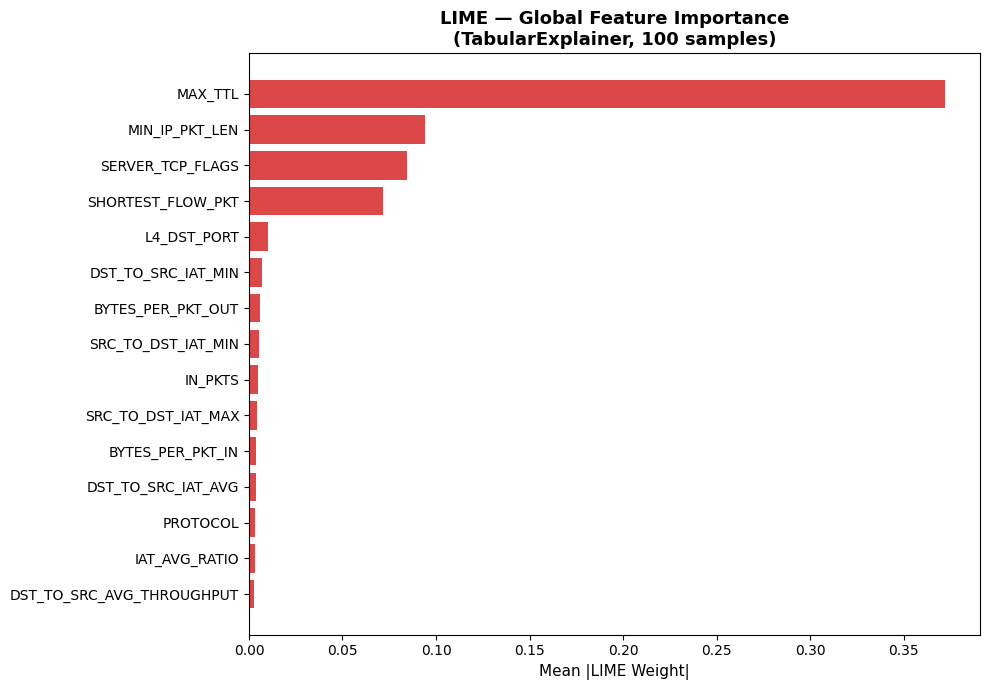


──────────────────────────────────────────────────────────────────────
[3] EFFICIENCY COMPARISON
──────────────────────────────────────────────────────────────────────

  SHAP (TreeExplainer):
    Total  : 5.40s  for 500 samples
    Per-sample: 10.79 ms
    Method : Exact Shapley values via tree structure traversal

  LIME (TabularExplainer):
    Total  : 17.06s  for 100 samples
    Per-sample: 170.60 ms
    Method : Local linear approximation with perturbation sampling

  SHAP is ~16x faster per sample than LIME.
  SHAP is recommended for real-time IDS inference.
  LIME is useful for per-instance debugging and auditing.



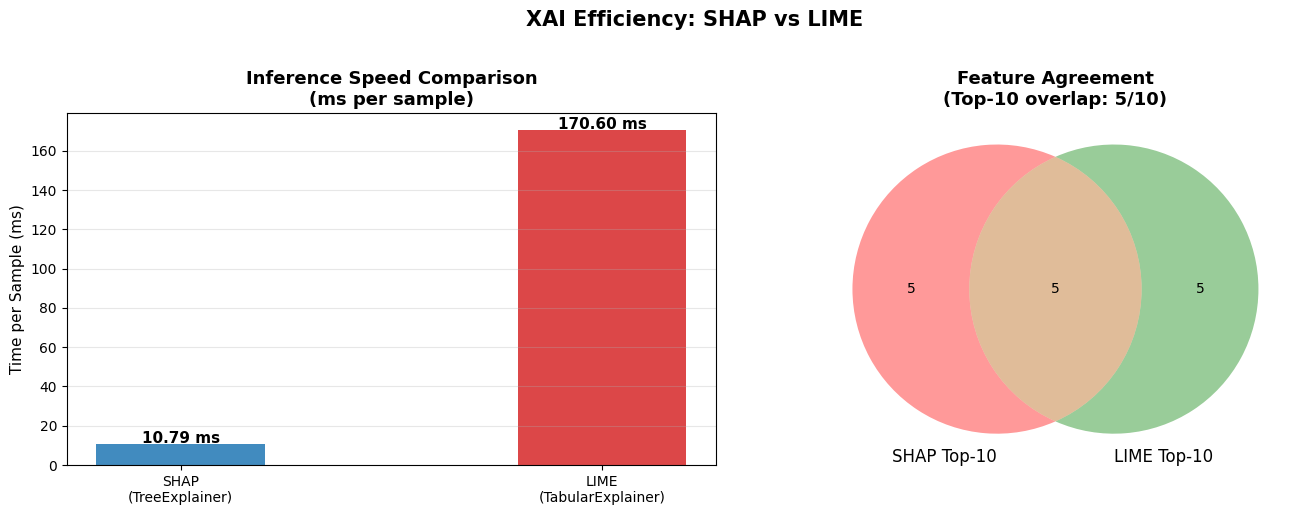


──────────────────────────────────────────────────────────────────────
[4] RELIABILITY & CONSISTENCY
──────────────────────────────────────────────────────────────────────

  Spearman Rank Correlation (SHAP vs LIME rankings):
    ρ = 0.2723  (p = 0.0850)
    Weak agreement

  Top-K Feature Agreement:
    Top-5  : 4/5  features shared  (80%)
    Top-10 : 5/10 features shared  (50%)
    Top-15 : 7/15 features shared  (47%)

  Consensus top-4 (highest ranked by both methods):

    MAX_TTL                           SHAP rank:  1  |  LIME rank:  1
    MIN_IP_PKT_LEN                    SHAP rank:  2  |  LIME rank:  2
    SERVER_TCP_FLAGS                  SHAP rank:  3  |  LIME rank:  3
    SHORTEST_FLOW_PKT                 SHAP rank:  4  |  LIME rank:  4


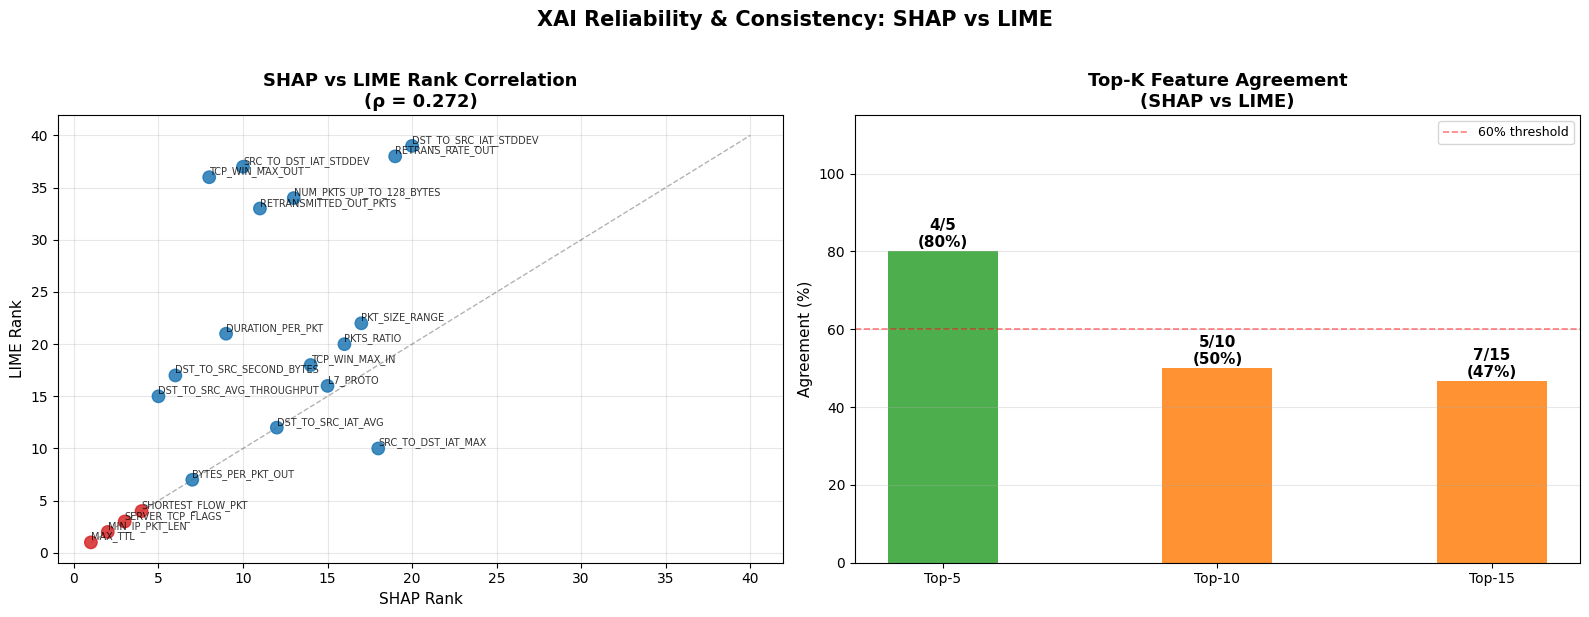


XAI BENCHMARKING SUMMARY

  [1] SHAP  : 5.4s total  |  10.79 ms/sample  |  Exact Shapley (tree-native)
  [2] LIME  : 17.1s total  |  170.60 ms/sample  |  Local linear approximation
  [3] Speed : SHAP is ~16x faster per sample
  [4] Agreement: ρ = 0.272 | Top-10 overlap = 5/10
  Recommendation: Use SHAP for real-time scoring, LIME for offline auditing.



In [21]:
# ===== Step 21: XAI Benchmarking & Evaluation =====
# Diagram layer: SHAP analysis, LIME analysis, Efficiency comparison, Reliability & consistency

import subprocess, sys

def _install(pkg):
    try:
        __import__(pkg)
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        print(f"  {pkg} installed.")

_install("shap")
_install("lime")

import shap
import lime
import lime.lime_tabular
import time as _time
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("XAI BENCHMARKING & EVALUATION")
print("=" * 70)

# ═══════════════════════════════════════════════════════════════════
# Shared sample for all methods (same 500 samples for fair comparison)
# ═══════════════════════════════════════════════════════════════════
N_SAMPLES = 500
rng_bench = np.random.RandomState(0)
bench_idx = rng_bench.choice(len(X_test), size=N_SAMPLES, replace=False)
X_bench = X_test.iloc[bench_idx]
y_bench = y_test_bin.iloc[bench_idx]
feature_names_list = list(X_train.columns)

print(f"\n  Benchmark sample: {N_SAMPLES} records "
      f"({y_bench.sum()} attack, {(~y_bench.astype(bool)).sum()} normal)")

# ═══════════════════════════════════════════════════════════════════
# [1] SHAP Analysis
# ═══════════════════════════════════════════════════════════════════
print(f"\n{'─' * 70}")
print("[1] SHAP ANALYSIS  (TreeExplainer — exact, model-native)")
print(f"{'─' * 70}")

t_shap_start = _time.time()
explainer_shap = shap.TreeExplainer(rf_model)
shap_values_raw = explainer_shap.shap_values(X_bench)
t_shap = _time.time() - t_shap_start

# Handle 3D output (n_samples, n_features, n_classes)
if isinstance(shap_values_raw, list):
    shap_vals_attack = shap_values_raw[1]
elif shap_values_raw.ndim == 3:
    shap_vals_attack = shap_values_raw[:, :, 1]
else:
    shap_vals_attack = shap_values_raw

mean_abs_shap = np.abs(shap_vals_attack).mean(axis=0)
shap_ranking = pd.DataFrame({
    'Feature': feature_names_list,
    'Mean_SHAP': mean_abs_shap
}).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)

print(f"\n  Elapsed: {t_shap:.1f}s  |  Top 10 features by mean |SHAP|:\n")
for i, row in shap_ranking.head(10).iterrows():
    bar = "█" * int(row['Mean_SHAP'] / shap_ranking['Mean_SHAP'].max() * 25)
    print(f"  {i+1:>2}. {row['Feature']:<32} {row['Mean_SHAP']:.5f}  {bar}")

# SHAP summary bar plot
print("\n  Generating SHAP summary bar plot...")
fig, ax = plt.subplots(figsize=(10, 7))
top15_shap = shap_ranking.head(15)
ax.barh(range(14, -1, -1), top15_shap['Mean_SHAP'].values, color='#1f77b4', alpha=0.85)
ax.set_yticks(range(14, -1, -1))
ax.set_yticklabels(top15_shap['Feature'].values, fontsize=10)
ax.set_xlabel('Mean |SHAP Value|', fontsize=11)
ax.set_title('SHAP — Global Feature Importance\n(TreeExplainer, 500 samples)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# [2] LIME Analysis
# ═══════════════════════════════════════════════════════════════════
print(f"\n{'─' * 70}")
print("[2] LIME ANALYSIS  (TabularExplainer — local, model-agnostic)")
print(f"{'─' * 70}")

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names_list,
    class_names=['Normal', 'Attack'],
    mode='classification',
    random_state=42
)

N_LIME = 100   # LIME is slow — use 100 samples
lime_idx = rng_bench.choice(len(X_bench), size=N_LIME, replace=False)
X_lime_sample = X_bench.iloc[lime_idx]

t_lime_start = _time.time()
lime_importances = np.zeros(len(feature_names_list))
feat_name_to_idx = {name: i for i, name in enumerate(feature_names_list)}

for i in range(N_LIME):
    exp = explainer_lime.explain_instance(
        X_lime_sample.values[i],
        rf_model.predict_proba,
        num_features=len(feature_names_list),
        top_labels=1
    )
    label_key = 1 if 1 in exp.available_labels() else exp.available_labels()[0]
    for feat_rule, weight in exp.as_list(label=label_key):
        # Match rule back to feature name
        for fname in feature_names_list:
            if fname in feat_rule:
                lime_importances[feat_name_to_idx[fname]] += abs(weight)
                break

t_lime = _time.time() - t_lime_start

lime_ranking = pd.DataFrame({
    'Feature': feature_names_list,
    'Mean_LIME': lime_importances / N_LIME
}).sort_values('Mean_LIME', ascending=False).reset_index(drop=True)

print(f"\n  Elapsed: {t_lime:.1f}s  |  Top 10 features by mean |LIME weight|:\n")
for i, row in lime_ranking.head(10).iterrows():
    bar = "█" * int(row['Mean_LIME'] / (lime_ranking['Mean_LIME'].max() + 1e-9) * 25)
    print(f"  {i+1:>2}. {row['Feature']:<32} {row['Mean_LIME']:.5f}  {bar}")

# LIME summary bar plot
fig, ax = plt.subplots(figsize=(10, 7))
top15_lime = lime_ranking.head(15)
ax.barh(range(14, -1, -1), top15_lime['Mean_LIME'].values, color='#d62728', alpha=0.85)
ax.set_yticks(range(14, -1, -1))
ax.set_yticklabels(top15_lime['Feature'].values, fontsize=10)
ax.set_xlabel('Mean |LIME Weight|', fontsize=11)
ax.set_title('LIME — Global Feature Importance\n(TabularExplainer, 100 samples)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# [3] Efficiency Comparison
# ═══════════════════════════════════════════════════════════════════
print(f"\n{'─' * 70}")
print("[3] EFFICIENCY COMPARISON")
print(f"{'─' * 70}")

shap_per_sample = t_shap / N_SAMPLES * 1000  # ms per sample
lime_per_sample = t_lime / N_LIME * 1000
speedup = t_lime / (t_shap + 1e-9) * (N_LIME / N_SAMPLES)  # normalized speedup

print(f"""
  SHAP (TreeExplainer):
    Total  : {t_shap:.2f}s  for {N_SAMPLES} samples
    Per-sample: {shap_per_sample:.2f} ms
    Method : Exact Shapley values via tree structure traversal

  LIME (TabularExplainer):
    Total  : {t_lime:.2f}s  for {N_LIME} samples
    Per-sample: {lime_per_sample:.2f} ms
    Method : Local linear approximation with perturbation sampling

  SHAP is ~{lime_per_sample/shap_per_sample:.0f}x faster per sample than LIME.
  SHAP is recommended for real-time IDS inference.
  LIME is useful for per-instance debugging and auditing.
""")

# Efficiency bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = ['SHAP\n(TreeExplainer)', 'LIME\n(TabularExplainer)']
times_per_sample = [shap_per_sample, lime_per_sample]
bar_colors_eff = ['#1f77b4', '#d62728']
bars = axes[0].bar(methods, times_per_sample, color=bar_colors_eff, alpha=0.85, width=0.4)
for b, v in zip(bars, times_per_sample):
    axes[0].text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.2f} ms',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Time per Sample (ms)', fontsize=11)
axes[0].set_title('Inference Speed Comparison\n(ms per sample)', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

top_n = 10
shap_top = set(shap_ranking.head(top_n)['Feature'])
lime_top = set(lime_ranking.head(top_n)['Feature'])
overlap = shap_top & lime_top
try:
    from matplotlib_venn import venn2  # optional — fallback to bar if missing
    venn2([shap_top, lime_top], set_labels=(f'SHAP Top-{top_n}', f'LIME Top-{top_n}'), ax=axes[1])
    axes[1].set_title(f'Feature Agreement\n(Top-{top_n} overlap: {len(overlap)}/{top_n})',
                      fontsize=13, fontweight='bold')
except Exception:
    # Fallback: grouped bar for shared vs unique features
    cats = ['Shared', 'SHAP only', 'LIME only']
    vals = [len(overlap), len(shap_top - lime_top), len(lime_top - shap_top)]
    bar_c = ['#2ca02c', '#1f77b4', '#d62728']
    axes[1].bar(cats, vals, color=bar_c, alpha=0.85, width=0.5)
    axes[1].set_ylabel('Feature Count', fontsize=11)
    axes[1].set_title(f'Top-{top_n} Feature Agreement\n(SHAP vs LIME)', fontsize=13, fontweight='bold')
    for b, v in zip(axes[1].patches, vals):
        axes[1].text(b.get_x() + b.get_width()/2, v + 0.05, str(v),
                     ha='center', fontsize=12, fontweight='bold')

plt.suptitle('XAI Efficiency: SHAP vs LIME', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════
# [4] Reliability & Consistency
# ═══════════════════════════════════════════════════════════════════
print(f"\n{'─' * 70}")
print("[4] RELIABILITY & CONSISTENCY")
print(f"{'─' * 70}")

from scipy.stats import spearmanr

# Merge top-15 ranks from both methods on shared features
merged_rank = shap_ranking[['Feature', 'Mean_SHAP']].merge(
    lime_ranking[['Feature', 'Mean_LIME']], on='Feature'
)
merged_rank['SHAP_Rank'] = merged_rank['Mean_SHAP'].rank(ascending=False).astype(int)
merged_rank['LIME_Rank'] = merged_rank['Mean_LIME'].rank(ascending=False).astype(int)

rho, p_val = spearmanr(merged_rank['SHAP_Rank'], merged_rank['LIME_Rank'])

# Top-k agreement at k=5,10,15
agreements = {}
for k in [5, 10, 15]:
    sh_top = set(shap_ranking.head(k)['Feature'])
    li_top = set(lime_ranking.head(k)['Feature'])
    agreements[k] = len(sh_top & li_top)

print(f"""
  Spearman Rank Correlation (SHAP vs LIME rankings):
    ρ = {rho:.4f}  (p = {p_val:.4f})
    {"Strong agreement" if abs(rho) > 0.7 else "Moderate agreement" if abs(rho) > 0.4 else "Weak agreement"}

  Top-K Feature Agreement:
    Top-5  : {agreements[5]}/5  features shared  ({agreements[5]/5*100:.0f}%)
    Top-10 : {agreements[10]}/10 features shared  ({agreements[10]/10*100:.0f}%)
    Top-15 : {agreements[15]}/15 features shared  ({agreements[15]/15*100:.0f}%)

  Consensus top-4 (highest ranked by both methods):
""")

merged_rank['Avg_Rank'] = (merged_rank['SHAP_Rank'] + merged_rank['LIME_Rank']) / 2
consensus = merged_rank.sort_values('Avg_Rank').head(4)
for _, row in consensus.iterrows():
    print(f"    {row['Feature']:<32}  SHAP rank: {row['SHAP_Rank']:>2}  |  LIME rank: {row['LIME_Rank']:>2}")

# Consistency scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top20_merged = merged_rank.head(20)
axes[0].scatter(top20_merged['SHAP_Rank'], top20_merged['LIME_Rank'],
                color=['#d62728' if r <= 4 else '#1f77b4' for r in top20_merged['Avg_Rank']],
                s=80, alpha=0.85, zorder=3)
for _, row in top20_merged.iterrows():
    axes[0].annotate(row['Feature'], (row['SHAP_Rank'], row['LIME_Rank']),
                     fontsize=7, ha='left', va='bottom', alpha=0.8)
# Add diagonal reference line
max_rank = max(top20_merged['SHAP_Rank'].max(), top20_merged['LIME_Rank'].max()) + 1
axes[0].plot([1, max_rank], [1, max_rank], 'k--', alpha=0.3, lw=1)
axes[0].set_xlabel('SHAP Rank', fontsize=11)
axes[0].set_ylabel('LIME Rank', fontsize=11)
axes[0].set_title(f'SHAP vs LIME Rank Correlation\n(ρ = {rho:.3f})', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Agreement bars
k_vals = list(agreements.keys())
agree_pct = [agreements[k] / k * 100 for k in k_vals]
bars = axes[1].bar([f'Top-{k}' for k in k_vals], agree_pct,
                   color=['#2ca02c' if v >= 60 else '#ff7f0e' for v in agree_pct],
                   alpha=0.85, width=0.4)
for b, pct, k in zip(bars, agree_pct, k_vals):
    axes[1].text(b.get_x() + b.get_width()/2, pct + 1,
                 f'{agreements[k]}/{k}\n({pct:.0f}%)', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Agreement (%)', fontsize=11)
axes[1].set_ylim([0, 115])
axes[1].set_title('Top-K Feature Agreement\n(SHAP vs LIME)', fontsize=13, fontweight='bold')
axes[1].axhline(60, color='red', linestyle='--', lw=1.2, alpha=0.5, label='60% threshold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('XAI Reliability & Consistency: SHAP vs LIME', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n{'=' * 70}")
print("XAI BENCHMARKING SUMMARY")
print("=" * 70)
print(f"""
  [1] SHAP  : {t_shap:.1f}s total  |  {shap_per_sample:.2f} ms/sample  |  Exact Shapley (tree-native)
  [2] LIME  : {t_lime:.1f}s total  |  {lime_per_sample:.2f} ms/sample  |  Local linear approximation
  [3] Speed : SHAP is ~{lime_per_sample/shap_per_sample:.0f}x faster per sample
  [4] Agreement: ρ = {rho:.3f} | Top-10 overlap = {agreements[10]}/10
  Recommendation: Use SHAP for real-time scoring, LIME for offline auditing.
""")
print("=" * 70)

In [22]:
# ===== Export Model & Artifacts for Middleware =====
import joblib
import json
import os

os.makedirs('model', exist_ok=True)

# 1. Save the trained Random Forest model
joblib.dump(rf_model, 'model/rf_model.joblib')
print(f"Model saved  →  model/rf_model.joblib")

# 2. Save the exact ordered list of feature columns the model expects
feature_names = list(X_train.columns)
with open('model/feature_names.json', 'w') as f:
    json.dump(feature_names, f, indent=2)
print(f"Feature list saved  →  model/feature_names.json  ({len(feature_names)} features)")

# 3. Save the correlated columns that were dropped (for documentation)
dropped_corr = sorted(list(to_drop)) if 'to_drop' in dir() else []
with open('model/dropped_correlated.json', 'w') as f:
    json.dump(dropped_corr, f, indent=2)
print(f"Dropped columns saved  →  model/dropped_correlated.json  ({len(dropped_corr)} cols)")

# 4. Save model metadata
metadata = {
    "model_type": "RandomForestClassifier",
    "n_estimators": rf_model.n_estimators,
    "n_features": len(feature_names),
    "feature_names": feature_names,
    "classes": rf_model.classes_.tolist(),
    "class_mapping": {"0": "Normal", "1": "Attack"},
    "performance": {
        "accuracy": round(float(acc), 6),
        "precision": round(float(prec), 6),
        "recall": round(float(rec), 6),
        "f1_score": round(float(f1), 6),
        "roc_auc": round(float(auc), 6),
    },
    "web_ports": [80, 443, 8080, 8443, 8000, 8888, 3000, 5000],
    "irrelevant_cols": [
        'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID',
        'DNS_QUERY_TYPE', 'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE',
        'FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS',
        'IPV4_SRC_ADDR', 'IPV4_DST_ADDR'
    ],
    "dropped_correlated": dropped_corr
}

with open('model/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata saved  →  model/metadata.json")

print(f"\n{'=' * 50}")
print(f"All middleware artifacts saved to model/")
print(f"Run:  cd middleware && uvicorn app:app --reload")

Model saved  →  model/rf_model.joblib
Feature list saved  →  model/feature_names.json  (41 features)
Dropped columns saved  →  model/dropped_correlated.json  (14 cols)
Metadata saved  →  model/metadata.json

All middleware artifacts saved to model/
Run:  cd middleware && uvicorn app:app --reload
